# Welcome to the JULO Data Science Take Home Assignment

JULO provides virtual credit limits to it's customers to meet a wide array of customer financing needs. We have provided you with some data related to our customer's loan applications, loan details and their repayment history.

JULO wants to use this data to improve their risk management, and asks you to use your Data Science skills to derive valuable insights from the data and to build a predictive credit score model to aid in future customer credit decisions.

**Requirements:**
1. You have 7 days to report on the assignment
2. Please use python to solve this exercise. You can use libraries such as: sqlalchemy, pandas, or any other packages of your choice that can help you work on the assignments
3. For visualizations, please use python and its common libraries
4. When you are prompted to use sql, please use sqlalchemy for that assignment

**Deliverables:**
1. Python Jupyter notebook with your code (please comment the code! this let us follow your thought process)
2. In addition, also save your notebooks in .html file and attach it with the actual code

**What are we looking for:**
1. Story from the data (Completeness of analysis/ story)
2. There is no right solution to this assignment
3. Your thought process (Be precise, straight to the point, and remember to comment the code)
4. The rationale behind the decisions you made (Provide justifications to your recommendations)

In [ ]:
#!pip install pandas==1.4.16

In [ ]:
#pip install pandas --upgrade

In [ ]:
#pip install sqlalchemy --upgrade

In [ ]:
#pip install dataprep --upgrade

In [ ]:
#pip install SQLAlchemy==1.4.17

In [ ]:
import numpy as np
import pandas as pd
import sqlalchemy as sa
path = 'data/'

We have already prepared a database for you to query from

In [ ]:
 # Create SQL Alchemy Engine
engine = sa.create_engine('sqlite:///database.db')

In [ ]:
# Import data as pd.DataFrame
application_df = pd.read_csv(path + 'application.csv')
loan_df = pd.read_csv(path + 'loan.csv')
payment1_df = pd.read_csv(path + 'payment1.csv')
payment2_df = pd.read_csv(path + 'payment2.csv')

In [ ]:
# Insert data from pd.DataFrame to SQL Alchemy Engine
application_df.to_sql(name='application', con=engine,if_exists='replace')
loan_df.to_sql(name='loan', con=engine,if_exists='replace')
payment1_df.to_sql(name='payment1', con=engine,if_exists='replace')
payment2_df.to_sql(name='payment2', con=engine,if_exists='replace')

17911

In [ ]:
def query_from_db(sql_long_string, engine):
    """
    Execute SQL Statement and return the queried data as a pandas.DataFrame object

    :param sql_long_string: SQL statement
    :param engine: SQL Alchemy engine
    """

    conn = engine.connect()
    statement = conn.execute(sql_long_string)
    df = pd.DataFrame(statement.fetchall())
    df.columns = statement.keys()
    return df

### Assignment 1 - Data Preparation and Cleaning

Please do all these tasks in SQL query.
1. Combine all the tables into a single dataframe.
2. Do you notice anything suspicious with the dataframe? If yes, please do a preliminary analysis and fix it. Explain what you found and how you fix it.
3. Do you see any outliers? Explain how do you detect the outlier and how you fix it.
4. Provide your assumptions on the data.

#### 1.1 Table Merge


In [ ]:
# print using pandas
application_df.head()

,Unnamed: 0,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,job_industry
0,0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,Admin / Finance / HR
1,1,2021-01-14 15:56:27.403268+00:00,2004025736661,2.003024e+12,Modal usaha,saya ingin menambah modal saya untuk berjualan...,1986-07-22,Banten,Menikah,2.0,Pegawai swasta,Admin / Finance / HR
2,2,2021-02-07 05:21:46.225530+00:00,2004025885365,2.003023e+12,Kebutuhan sehari-hari,banyak pengeluaran bulan ini jadi ngk ketutup ...,NaN,NaN,Lajang,0.0,Pegawai swasta,Pabrik / Gudang
3,3,2021-04-22 07:15:09.482447+00:00,2004026435734,2.003024e+12,Modal usaha,NaN,1996-01-16,Jawa Barat,Menikah,1.0,Pegawai swasta,Pabrik / Gudang
4,4,2021-02-07 14:57:21.120284+00:00,2004025890269,2.003024e+12,Renovasi Rumah,Untuk renovasi rumah yg saat ini ada masalah p...,1992-06-13,NaN,NaN,0.0,Pegawai swasta,Sales / Marketing


In [ ]:
app = query_from_db("select * from application", engine)
app

,index,Unnamed: 0,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,job_industry
0,0,0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,Admin / Finance / HR
1,1,1,2021-01-14 15:56:27.403268+00:00,2004025736661,2.003024e+12,Modal usaha,saya ingin menambah modal saya untuk berjualan...,1986-07-22,Banten,Menikah,2.0,Pegawai swasta,Admin / Finance / HR
2,2,2,2021-02-07 05:21:46.225530+00:00,2004025885365,2.003023e+12,Kebutuhan sehari-hari,banyak pengeluaran bulan ini jadi ngk ketutup ...,None,None,Lajang,0.0,Pegawai swasta,Pabrik / Gudang
3,3,3,2021-04-22 07:15:09.482447+00:00,2004026435734,2.003024e+12,Modal usaha,None,1996-01-16,Jawa Barat,Menikah,1.0,Pegawai swasta,Pabrik / Gudang
4,4,4,2021-02-07 14:57:21.120284+00:00,2004025890269,2.003024e+12,Renovasi Rumah,Untuk renovasi rumah yg saat ini ada masalah p...,1992-06-13,None,None,0.0,Pegawai swasta,Sales / Marketing
...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,492,492,2021-02-16 09:14:30.426871+00:00,2004025950383,2.003024e+12,Renovasi Rumah,renovasi rumah harus dilakukan segera karena b...,1972-05-14,Jawa Barat,Menikah,3.0,Pengusaha,Transportasi
493,493,493,2021-05-06 04:04:23.798351+00:00,2004026541054,2.003024e+12,Kebutuhan sehari-hari,None,1994-02-05,Jawa Barat,Menikah,0.0,Pegawai swasta,Service
494,494,494,2021-06-09 02:39:48.937232+00:00,2004026770549,2.003024e+12,Kebutuhan sehari-hari,selamat pagi julo saya mengajukan limit julo k...,1992-04-11,Jawa Barat,None,0.0,Pegawai swasta,Hukum / Security / Politik
495,495,495,2021-03-11 03:39:05.688931+00:00,2004026118497,2.003024e+12,Biaya kesehatan,untuk biaya kesehatan orang tua dan membeli ob...,1999-10-29,Jawa Barat,Lajang,0.0,Pegawai swasta,Tehnik / Computer


In [ ]:
app.nunique()

index                497
Unnamed: 0           497
cdate                454
application_id       497
customer_id          451
loan_purpose          11
loan_purpose_desc    442
dob                  440
address_provinsi      32
marital_status         4
dependent              6
job_type               5
job_industry          16
dtype: int64

In [ ]:
loan = query_from_db("select * from loan", engine)
loan

,index,Unnamed: 0,loan_id,loan_amount,loan_duration,installment_amount,fund_transfer_ts,application_id
0,0,0,2.005021e+12,421632.0,5.0,113000.0,2021-10-28 02:53:53.512501+00:00,2.004027e+12
1,1,1,2.005021e+12,300000.0,3.0,118000.0,2021-04-10 15:20:20.480261+00:00,2.004026e+12
2,2,2,2.005021e+12,500000.0,6.0,113000.0,2021-02-23 08:27:53.192023+00:00,2.004026e+12
3,3,3,2.005021e+12,2500000.0,6.0,566000.0,2021-02-10 02:41:30.887286+00:00,2.004026e+12
4,4,4,2.005021e+12,500000.0,NaN,196000.0,2021-02-14 01:57:11.613161+00:00,2.004026e+12
...,...,...,...,...,...,...,...,...
5228,5228,5228,2.005021e+12,500000.0,5.0,140000.0,2021-07-09 03:17:44.062103+00:00,2.004026e+12
5229,5229,5229,2.005021e+12,526895.0,3.0,201000.0,2021-11-11 09:09:24.693283+00:00,2.004028e+12
5230,5230,5230,2.005021e+12,263737.0,3.0,101000.0,2021-11-15 04:27:13.157537+00:00,2.004028e+12
5231,5231,5231,2.005022e+12,700000.0,4.0,217000.0,2022-01-16 02:57:49.484083+00:00,2.004027e+12


In [ ]:
loan.nunique()

index                 5233
Unnamed: 0            5233
loan_id               5143
loan_amount            479
loan_duration            9
installment_amount    1352
fund_transfer_ts      5123
application_id         496
dtype: int64

In [ ]:
pay1 = query_from_db("SELECT * FROM payment1", engine)
pay1

,index,Unnamed: 0.1,Unnamed: 0,payment_id,payment_number,due_date,due_amount,paid_date,paid_amount,loan_id,dpd
0,0,0,0,2006021951630,1.0,2021-02-07,0.0,2021-03-08,1026000.0,2.005021e+12,29.0
1,1,1,1,2006021922761,1.0,2021-02-06,0.0,2021-03-08,152000.0,2.005021e+12,30.0
2,2,2,2,2006023224658,3.0,2021-10-21,0.0,2021-11-20,1083000.0,2.005021e+12,30.0
3,3,3,3,2006023527657,2.0,2021-10-21,0.0,2021-11-20,805000.0,2.005021e+12,30.0
4,4,4,4,2006021922762,2.0,2021-03-06,0.0,None,140000.0,2.005021e+12,NaN
...,...,...,...,...,...,...,...,...,...,...,...
17906,17906,17906,17906,2006057180789,5.0,None,87000.0,None,0.0,2.005022e+12,NaN
17907,17907,17907,17907,2006057180790,6.0,None,87000.0,None,0.0,2.005022e+12,NaN
17908,17908,17908,17908,2006057180971,1.0,2022-03-06,384000.0,None,0.0,2.005022e+12,NaN
17909,17909,17909,17909,2006057180972,2.0,2022-04-06,403000.0,None,0.0,2.005022e+12,NaN


In [ ]:
pay1.nunique()

index             17911
Unnamed: 0.1      17911
Unnamed: 0        17911
payment_id        17911
payment_number       13
due_date            471
due_amount         1264
paid_date           375
paid_amount        1899
loan_id            5217
dpd                 232
dtype: int64

In [ ]:
pay2 = query_from_db("SELECT * FROM payment2", engine)
pay2

,index,Unnamed: 0.1,Unnamed: 0,payment_id,payment_number,due_date,due_amount,paid_date,paid_amount,loan_id,dpd
0,0,0,0,2006021951630,1.0,2021-02-07,0.0,2021-03-08,1026000.0,2.005021e+12,29.0
1,1,1,1,2006021922761,1.0,2021-02-06,0.0,2021-03-08,152000.0,2.005021e+12,30.0
2,2,2,2,2006023224658,3.0,2021-10-21,0.0,2021-11-20,1083000.0,2.005021e+12,30.0
3,3,3,3,2006023527657,2.0,2021-10-21,0.0,2021-11-20,805000.0,2.005021e+12,30.0
4,4,4,4,2006021922762,2.0,2021-03-06,0.0,None,140000.0,2.005021e+12,NaN
...,...,...,...,...,...,...,...,...,...,...,...
17906,17906,17906,17906,2006057180789,5.0,None,87000.0,None,0.0,2.005022e+12,NaN
17907,17907,17907,17907,2006057180790,6.0,None,87000.0,None,0.0,2.005022e+12,NaN
17908,17908,17908,17908,2006057180971,1.0,2022-03-06,384000.0,None,0.0,2.005022e+12,NaN
17909,17909,17909,17909,2006057180972,2.0,2022-04-06,403000.0,None,0.0,2.005022e+12,NaN


In [ ]:
pay2.nunique()

index             17911
Unnamed: 0.1      17911
Unnamed: 0        17911
payment_id        17911
payment_number       13
due_date            471
due_amount         1264
paid_date           375
paid_amount        1899
loan_id            5217
dpd                 232
dtype: int64

In [ ]:
merge_df = query_from_db('''SELECT a.*,
                             b.*,
                             c.*,
                             d.*
                             FROM application a
                             LEFT JOIN loan b
                             ON a.application_id = b.application_id
                             LEFT JOIN payment1 c
                             ON b.loan_id = c.loan_id
                             LEFT JOIN payment2 d
                             ON c.loan_id = d.loan_id''', engine)

In [ ]:
merge_df.head()

,index,Unnamed: 0,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,...,Unnamed: 0.1,Unnamed: 0,payment_id,payment_number,due_date,due_amount,paid_date,paid_amount,loan_id,dpd
0,0,0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,...,200.0,200.0,2.006022e+12,2.0,2021-04-02,0.0,2021-05-16,195000.0,2.005021e+12,44.0
1,0,0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,...,1205.0,1205.0,2.006022e+12,5.0,None,0.0,2021-08-02,140000.0,2.005021e+12,NaN
2,0,0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,...,1206.0,1206.0,2.006022e+12,3.0,2021-05-02,NaN,2021-05-30,140000.0,2.005021e+12,28.0
3,0,0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,...,1207.0,1207.0,2.006022e+12,4.0,2021-06-02,0.0,2021-07-06,140000.0,2.005021e+12,34.0
4,0,0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,...,1574.0,1574.0,2.006022e+12,1.0,2021-03-02,0.0,2021-04-02,149000.0,2.005021e+12,31.0


In [ ]:
#check rows & columns
merge_df.shape

(83554, 43)

In [ ]:
#check columns name after combaining table
merge_df.columns

Index(['index', 'Unnamed: 0', 'cdate', 'application_id', 'customer_id',
       'loan_purpose', 'loan_purpose_desc', 'dob', 'address_provinsi',
       'marital_status', 'dependent', 'job_type', 'job_industry', 'index',
       'Unnamed: 0', 'loan_id', 'loan_amount', 'loan_duration',
       'installment_amount', 'fund_transfer_ts', 'application_id', 'index',
       'Unnamed: 0.1', 'Unnamed: 0', 'payment_id', 'payment_number',
       'due_date', 'due_amount', 'paid_date', 'paid_amount', 'loan_id', 'dpd',
       'index', 'Unnamed: 0.1', 'Unnamed: 0', 'payment_id', 'payment_number',
       'due_date', 'due_amount', 'paid_date', 'paid_amount', 'loan_id', 'dpd'],
      dtype='object')

In [ ]:
#remove unnecessary columns
merge_df1 = merge_df.drop(['Unnamed: 0', 'index', 'Unnamed: 0', 'index', 'Unnamed: 0.1', 'Unnamed: 0', 'index','Unnamed: 0.1', 'Unnamed: 0'],
        axis=1, inplace=False)

In [ ]:
merge_df1

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,loan_id,dpd,payment_id,payment_number,due_date,due_amount,paid_date,paid_amount,loan_id,dpd
0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,2.0,2021-04-02,0.0,2021-05-16,195000.0,2.005021e+12,44.0
1,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,5.0,None,0.0,2021-08-02,140000.0,2.005021e+12,NaN
2,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,3.0,2021-05-02,NaN,2021-05-30,140000.0,2.005021e+12,28.0
3,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,4.0,2021-06-02,0.0,2021-07-06,140000.0,2.005021e+12,34.0
4,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,1.0,2021-03-02,0.0,2021-04-02,149000.0,2.005021e+12,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83549,2021-03-24 05:31:55.764238+00:00,2004026221387,2.003024e+12,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,2.005022e+12,NaN,2.006048e+12,3.0,2022-04-30,42000.0,None,0.0,2.005022e+12,NaN
83550,2021-03-24 05:31:55.764238+00:00,2004026221387,2.003024e+12,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,2.005022e+12,NaN,2.006048e+12,1.0,2022-02-28,0.0,2022-03-06,45000.0,2.005022e+12,6.0
83551,2021-03-24 05:31:55.764238+00:00,2004026221387,2.003024e+12,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,2.005022e+12,6.0,2.006048e+12,2.0,2022-03-30,42000.0,None,0.0,2.005022e+12,NaN
83552,2021-03-24 05:31:55.764238+00:00,2004026221387,2.003024e+12,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,2.005022e+12,6.0,2.006048e+12,3.0,2022-04-30,42000.0,None,0.0,2.005022e+12,NaN


In [ ]:
#check columns name again
merge_df1.columns

Index(['cdate', 'application_id', 'customer_id', 'loan_purpose',
       'loan_purpose_desc', 'dob', 'address_provinsi', 'marital_status',
       'dependent', 'job_type', 'job_industry', 'loan_id', 'loan_amount',
       'loan_duration', 'installment_amount', 'fund_transfer_ts',
       'application_id', 'payment_id', 'payment_number', 'due_date',
       'due_amount', 'paid_date', 'paid_amount', 'loan_id', 'dpd',
       'payment_id', 'payment_number', 'due_date', 'due_amount', 'paid_date',
       'paid_amount', 'loan_id', 'dpd'],
      dtype='object')

In [ ]:
#remove duplicate columns
merge_drop = merge_df1.drop_duplicates(subset=['payment_id', 'payment_number', 'due_date',
                             'due_amount', 'paid_date', 'paid_amount', 'loan_id', 'dpd'], keep='last')

In [ ]:
merge_drop

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,loan_id,dpd,payment_id,payment_number,due_date,due_amount,paid_date,paid_amount,loan_id,dpd
0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,2.0,2021-04-02,0.0,2021-05-16,195000.0,2.005021e+12,44.0
1,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,5.0,None,0.0,2021-08-02,140000.0,2.005021e+12,NaN
2,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,3.0,2021-05-02,NaN,2021-05-30,140000.0,2.005021e+12,28.0
3,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,4.0,2021-06-02,0.0,2021-07-06,140000.0,2.005021e+12,34.0
4,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,1.0,2021-03-02,0.0,2021-04-02,149000.0,2.005021e+12,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83549,2021-03-24 05:31:55.764238+00:00,2004026221387,2.003024e+12,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,2.005022e+12,NaN,2.006048e+12,3.0,2022-04-30,42000.0,None,0.0,2.005022e+12,NaN
83550,2021-03-24 05:31:55.764238+00:00,2004026221387,2.003024e+12,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,2.005022e+12,NaN,2.006048e+12,1.0,2022-02-28,0.0,2022-03-06,45000.0,2.005022e+12,6.0
83551,2021-03-24 05:31:55.764238+00:00,2004026221387,2.003024e+12,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,2.005022e+12,6.0,2.006048e+12,2.0,2022-03-30,42000.0,None,0.0,2.005022e+12,NaN
83552,2021-03-24 05:31:55.764238+00:00,2004026221387,2.003024e+12,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,2.005022e+12,6.0,2.006048e+12,3.0,2022-04-30,42000.0,None,0.0,2.005022e+12,NaN


In [ ]:
#check columns name after drop duplication
merge_drop.columns

Index(['cdate', 'application_id', 'customer_id', 'loan_purpose',
       'loan_purpose_desc', 'dob', 'address_provinsi', 'marital_status',
       'dependent', 'job_type', 'job_industry', 'loan_id', 'loan_amount',
       'loan_duration', 'installment_amount', 'fund_transfer_ts',
       'application_id', 'payment_id', 'payment_number', 'due_date',
       'due_amount', 'paid_date', 'paid_amount', 'loan_id', 'dpd',
       'payment_id', 'payment_number', 'due_date', 'due_amount', 'paid_date',
       'paid_amount', 'loan_id', 'dpd'],
      dtype='object')

In [ ]:
merge_drop[['payment_id', 'payment_number', 'due_date',
       'due_amount', 'paid_date', 'paid_amount', 'loan_id', 'dpd',
       'payment_id', 'payment_number', 'due_date', 'due_amount', 'paid_date',
       'paid_amount', 'loan_id', 'dpd']].tail()

,payment_id,payment_id,payment_number,payment_number,due_date,due_date,due_amount,due_amount,paid_date,paid_date,...,due_amount,paid_date,paid_date,paid_amount,paid_amount,loan_id,loan_id,loan_id,dpd,dpd
83549,2.006048e+12,2.006048e+12,3.0,3.0,2022-04-30,2022-04-30,42000.0,42000.0,None,None,...,42000.0,None,None,0.0,0.0,2.005022e+12,2.005022e+12,2.005022e+12,NaN,NaN
83550,2.006048e+12,2.006048e+12,3.0,1.0,2022-04-30,2022-02-28,42000.0,0.0,None,2022-03-06,...,0.0,None,2022-03-06,0.0,45000.0,2.005022e+12,2.005022e+12,2.005022e+12,NaN,6.0
83551,2.006048e+12,2.006048e+12,1.0,2.0,2022-02-28,2022-03-30,0.0,42000.0,2022-03-06,None,...,42000.0,2022-03-06,None,45000.0,0.0,2.005022e+12,2.005022e+12,2.005022e+12,6.0,NaN
83552,2.006048e+12,2.006048e+12,1.0,3.0,2022-02-28,2022-04-30,0.0,42000.0,2022-03-06,None,...,42000.0,2022-03-06,None,45000.0,0.0,2.005022e+12,2.005022e+12,2.005022e+12,6.0,NaN
83553,2.006048e+12,2.006048e+12,1.0,1.0,2022-02-28,2022-02-28,0.0,0.0,2022-03-06,2022-03-06,...,0.0,2022-03-06,2022-03-06,45000.0,45000.0,2.005022e+12,2.005022e+12,2.005022e+12,6.0,6.0


In [ ]:
merge_df2 = merge_drop

In [ ]:
merge_df2.head()

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,loan_id,dpd,payment_id,payment_number,due_date,due_amount,paid_date,paid_amount,loan_id,dpd
0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,2.0,2021-04-02,0.0,2021-05-16,195000.0,2.005021e+12,44.0
1,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,5.0,None,0.0,2021-08-02,140000.0,2.005021e+12,NaN
2,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,3.0,2021-05-02,NaN,2021-05-30,140000.0,2.005021e+12,28.0
3,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,4.0,2021-06-02,0.0,2021-07-06,140000.0,2.005021e+12,34.0
4,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.005021e+12,44.0,2.006022e+12,1.0,2021-03-02,0.0,2021-04-02,149000.0,2.005021e+12,31.0


In [ ]:
#check info of the dataset
merge_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83467 entries, 0 to 83553
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cdate               75721 non-null  object 
 1   application_id      83467 non-null  int64  
 2   customer_id         74327 non-null  float64
 3   loan_purpose        74352 non-null  object 
 4   loan_purpose_desc   74801 non-null  object 
 5   dob                 76352 non-null  object 
 6   address_provinsi    74794 non-null  object 
 7   marital_status      74030 non-null  object 
 8   dependent           73199 non-null  float64
 9   job_type            75162 non-null  object 
 10  job_industry        76351 non-null  object 
 11  loan_id             83466 non-null  float64
 12  loan_amount         81653 non-null  float64
 13  loan_duration       81688 non-null  float64
 14  installment_amount  81509 non-null  float64
 15  fund_transfer_ts    81795 non-null  object 
 16  applicati

Duplicate key in file '/Users/anwarsan/.matplotlib/matplotlibrc', line 2 ('backend: TkAgg')
Duplicate key in file '/Users/anwarsan/.matplotlib/matplotlibrc', line 3 ('backend: TkAgg')
/var/folders/z2/fsr3hf6j6cn61s87b2hj3xxr0000gn/T/ipykernel_962/1875369791.py:2: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  import pandas_profiling


<AxesSubplot:>

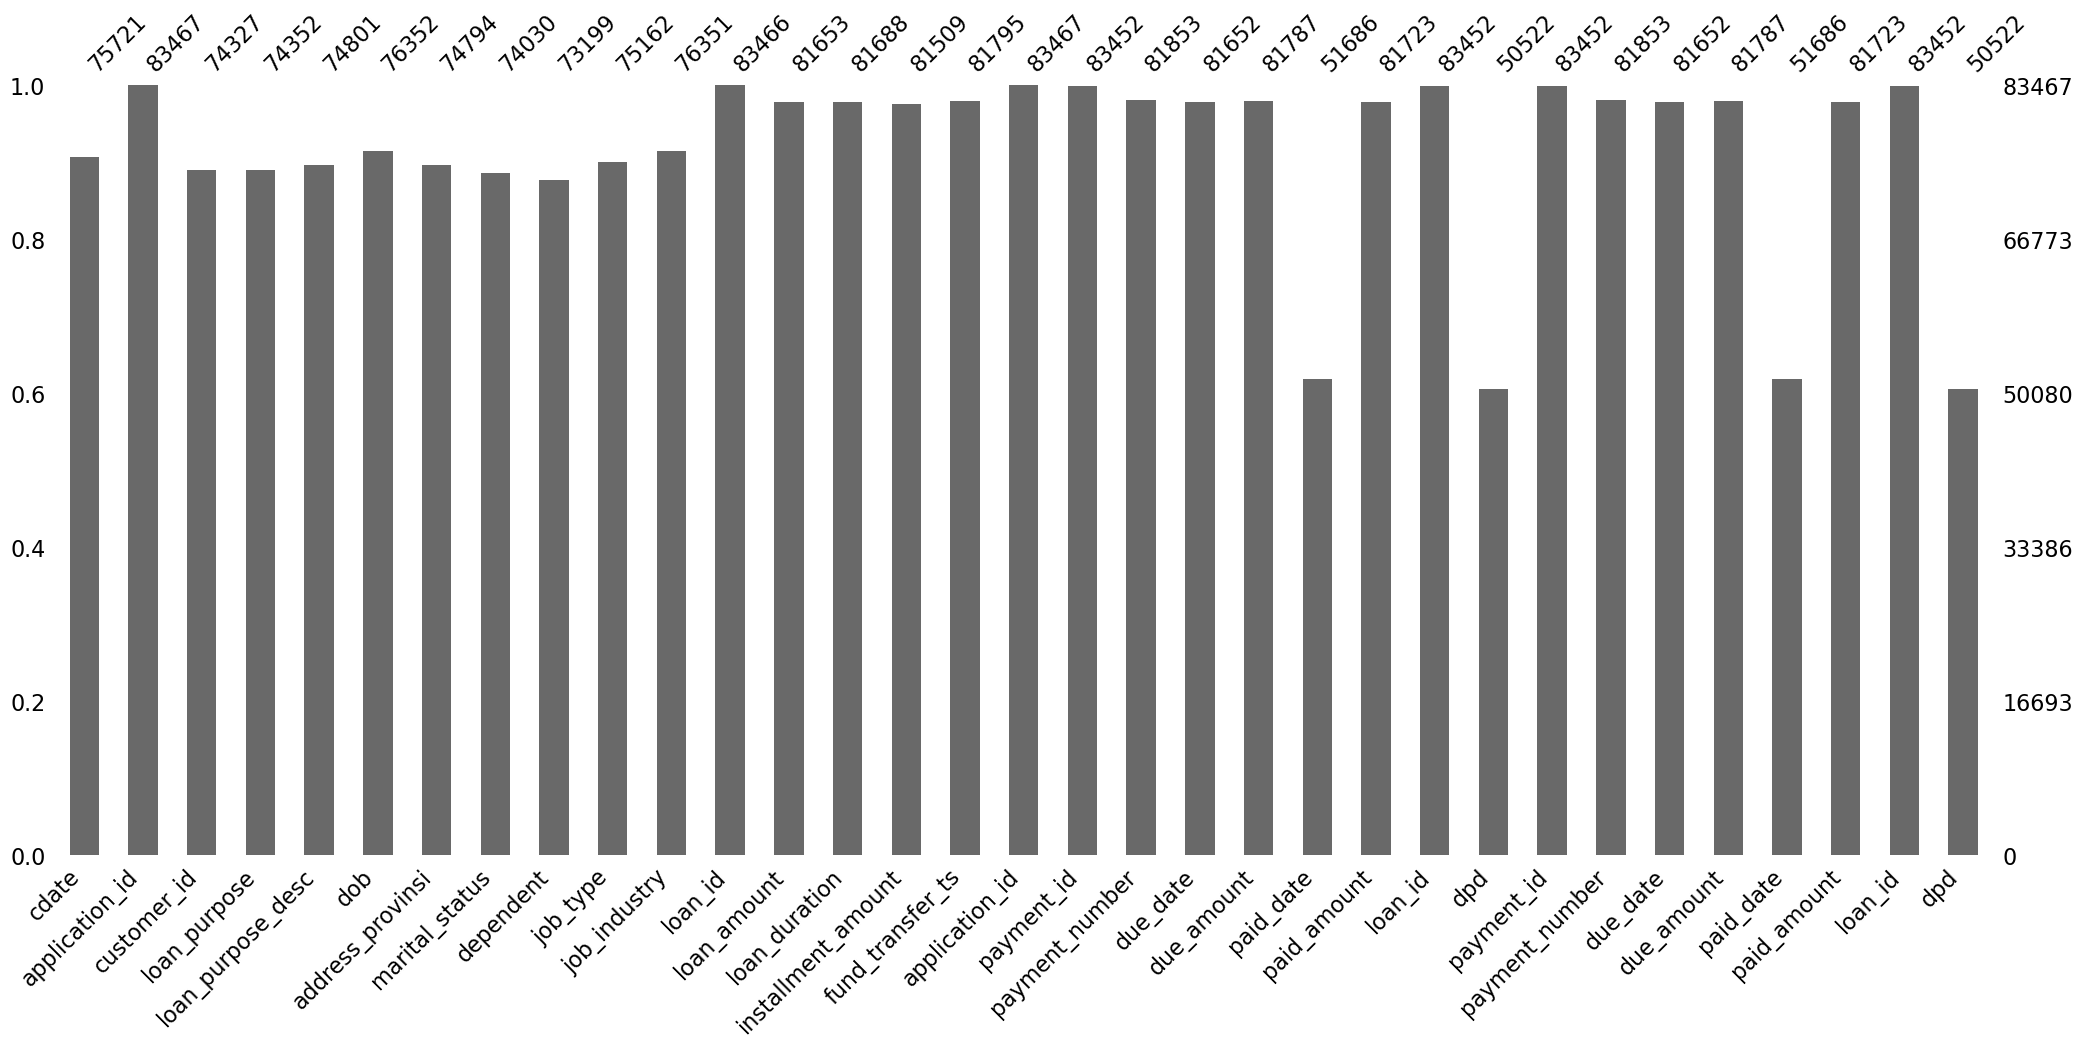

In [ ]:
#check missing values
import pandas_profiling
import missingno as msno
%matplotlib inline
msno.bar(merge_df2)

In [ ]:
#check columns name
merge_df2.columns

Index(['cdate', 'application_id', 'customer_id', 'loan_purpose',
       'loan_purpose_desc', 'dob', 'address_provinsi', 'marital_status',
       'dependent', 'job_type', 'job_industry', 'loan_id', 'loan_amount',
       'loan_duration', 'installment_amount', 'fund_transfer_ts',
       'application_id', 'payment_id', 'payment_number', 'due_date',
       'due_amount', 'paid_date', 'paid_amount', 'loan_id', 'dpd',
       'payment_id', 'payment_number', 'due_date', 'due_amount', 'paid_date',
       'paid_amount', 'loan_id', 'dpd'],
      dtype='object')

In [ ]:
# change columns name with index number for the next action to remove them because of duplication
merge_df2.columns.values[16]= 'appid'
merge_df2.columns.values[18]= 'payment_number_p1'
merge_df2.columns.values[19]= 'due_date_p1'
merge_df2.columns.values[20]= 'due_amount_p1'
merge_df2.columns.values[21]= 'paid_date_p1'
merge_df2.columns.values[22]= 'paid_amount_p1'
merge_df2.columns.values[23]= 'loanid'
merge_df2.columns.values[24]= 'dpd_p1'
merge_df2.columns.values[25]= 'paymentid'
merge_df2.columns.values[26]= 'payment_number_p2'
merge_df2.columns.values[27]= 'due_date_p2'
merge_df2.columns.values[28]= 'due_amount_p2'
merge_df2.columns.values[29]= 'paid_date_p2'
merge_df2.columns.values[30]= 'paid_amount_p2'
merge_df2.columns.values[31]= 'loanid_p1'
merge_df2.columns.values[32]= 'dpd_p2'

In [ ]:
merge_df2.columns

Index(['cdate', 'application_id', 'customer_id', 'loan_purpose',
       'loan_purpose_desc', 'dob', 'address_provinsi', 'marital_status',
       'dependent', 'job_type', 'job_industry', 'loan_id', 'loan_amount',
       'loan_duration', 'installment_amount', 'fund_transfer_ts', 'appid',
       'payment_id', 'payment_number_p1', 'due_date_p1', 'due_amount_p1',
       'paid_date_p1', 'paid_amount_p1', 'loanid', 'dpd_p1', 'paymentid',
       'payment_number_p2', 'due_date_p2', 'due_amount_p2', 'paid_date_p2',
       'paid_amount_p2', 'loanid_p1', 'dpd_p2'],
      dtype='object')

In [ ]:
#drop duplicate columns
df = merge_df2.drop(['appid', 'loanid', 'paymentid','loanid_p1' ], axis=1, inplace=False)

In [ ]:
df.head()

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_date_p2,due_amount_p2,paid_date_p2,paid_amount_p2,dpd_p2
0,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,2.0,2021-04-02,0.0,2021-05-16,195000.0,44.0
1,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,5.0,None,0.0,2021-08-02,140000.0,NaN
2,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,3.0,2021-05-02,NaN,2021-05-30,140000.0,28.0
3,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,4.0,2021-06-02,0.0,2021-07-06,140000.0,34.0
4,2021-01-07 13:45:43.876693+00:00,2004025695250,2.003024e+12,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,1.0,2021-03-02,0.0,2021-04-02,149000.0,31.0


In [ ]:
#check columns name
df.columns

Index(['cdate', 'application_id', 'customer_id', 'loan_purpose',
       'loan_purpose_desc', 'dob', 'address_provinsi', 'marital_status',
       'dependent', 'job_type', 'job_industry', 'loan_id', 'loan_amount',
       'loan_duration', 'installment_amount', 'fund_transfer_ts', 'payment_id',
       'payment_number_p1', 'due_date_p1', 'due_amount_p1', 'paid_date_p1',
       'paid_amount_p1', 'dpd_p1', 'payment_number_p2', 'due_date_p2',
       'due_amount_p2', 'paid_date_p2', 'paid_amount_p2', 'dpd_p2'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83467 entries, 0 to 83553
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cdate               75721 non-null  object 
 1   application_id      83467 non-null  int64  
 2   customer_id         74327 non-null  float64
 3   loan_purpose        74352 non-null  object 
 4   loan_purpose_desc   74801 non-null  object 
 5   dob                 76352 non-null  object 
 6   address_provinsi    74794 non-null  object 
 7   marital_status      74030 non-null  object 
 8   dependent           73199 non-null  float64
 9   job_type            75162 non-null  object 
 10  job_industry        76351 non-null  object 
 11  loan_id             83466 non-null  float64
 12  loan_amount         81653 non-null  float64
 13  loan_duration       81688 non-null  float64
 14  installment_amount  81509 non-null  float64
 15  fund_transfer_ts    81795 non-null  object 
 16  payment_i

In [ ]:
#check missing values
#all columns have missing values, except application_id
df.isnull().sum()

cdate                  7746
application_id            0
customer_id            9140
loan_purpose           9115
loan_purpose_desc      8666
dob                    7115
address_provinsi       8673
marital_status         9437
dependent             10268
job_type               8305
job_industry           7116
loan_id                   1
loan_amount            1814
loan_duration          1779
installment_amount     1958
fund_transfer_ts       1672
payment_id               15
payment_number_p1      1614
due_date_p1            1815
due_amount_p1          1680
paid_date_p1          31781
paid_amount_p1         1744
dpd_p1                32945
payment_number_p2      1614
due_date_p2            1815
due_amount_p2          1680
paid_date_p2          31781
paid_amount_p2         1744
dpd_p2                32945
dtype: int64

In [ ]:
# regardless do it right of missing values handling, we force all na columns filled by 0
df.loan_id = df.loan_id.fillna(0) ## should be dropna since there is 1 row na
df.fund_transfer_ts = df.fund_transfer_ts.fillna(0)
df.customer_id = df.customer_id.fillna(0)
df.cdate = df.cdate.fillna(0)
df.due_date_p1 = df.due_date_p1.fillna(0)
df.paid_date_p1 = df.paid_date_p1.fillna(0)
df.due_date_p2 = df.due_date_p2.fillna(0)
df.paid_date_p2 = df.paid_date_p2.fillna(0)
df.dob = df.dob.fillna(0)

In [ ]:
#Data type conversion
df.loan_id = df.loan_id.astype(int)
df.application_id = df.application_id.astype(int)
df.fund_transfer_ts = pd.to_datetime(df.fund_transfer_ts, errors='coerce', utc=True).dt.strftime('%Y-%m-%d %X')
df.customer_id = df.customer_id.astype(int)
df.cdate = pd.to_datetime(df.cdate, errors='coerce', utc=True).dt.strftime('%Y-%m-%d %X')
df.cdate = df.cdate.astype('datetime64[ns]')
df.due_date_p1 = pd.to_datetime(df.due_date_p1, errors='coerce', utc=True).dt.strftime('%Y-%m-%d')
df.due_date_p1 = df.due_date_p1.astype('datetime64[ns]')
df.paid_date_p1 = pd.to_datetime(df.paid_date_p1, errors='coerce', utc=True).dt.strftime('%Y-%m-%d')
df.paid_date_p1 = df.paid_date_p1.astype('datetime64[ns]')
df.due_date_p2 = pd.to_datetime(df.due_date_p2, errors='coerce', utc=True).dt.strftime('%Y-%m-%d')
df.due_date_p2 = df.due_date_p2.astype('datetime64[ns]')
df.paid_date_p2 = pd.to_datetime(df.paid_date_p2, errors='coerce', utc=True).dt.strftime('%Y-%m-%d')
df.paid_date_p2 = df.paid_date_p2.astype('datetime64[ns]')
df.dob = pd.to_datetime(df.dob, errors='coerce', utc=True).dt.strftime('%Y-%m-%d')
df.dob = df.dob.astype('datetime64[ns]')

In [ ]:
df.shape

(83467, 29)

In [ ]:
#select numerical features
selected_columns = ["loan_amount", "loan_duration", "installment_amount","payment_number_p1",
                    "due_amount_p1", "paid_amount_p1", "dpd_p1", "payment_number_p2","due_amount_p2","paid_amount_p2",
                    "dpd_p2"]

In [ ]:
#Check stat desc on numerical features as a base to fill missing values
df[selected_columns].describe()

,loan_amount,loan_duration,installment_amount,payment_number_p1,due_amount_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_amount_p2,paid_amount_p2,dpd_p2
count,8.165300e+04,81688.000000,8.150900e+04,81853.000000,8.178700e+04,8.172300e+04,50522.000000,81853.000000,8.178700e+04,8.172300e+04,50522.000000
mean,2.262062e+06,5.790336,4.803681e+05,3.493995,1.746704e+05,2.830639e+05,11.112901,3.493995,1.746704e+05,2.830639e+05,11.112901
std,2.706725e+06,2.099027,4.954904e+05,2.102160,3.883213e+05,4.377387e+05,36.092435,2.102160,3.883213e+05,4.377387e+05,36.092435
min,8.061000e+03,1.000000,8.888000e+03,1.000000,-5.353000e+05,0.000000e+00,-230.000000,1.000000,-5.353000e+05,0.000000e+00,-230.000000
25%,5.000000e+05,4.000000,1.310000e+05,2.000000,0.000000e+00,0.000000e+00,7.000000,2.000000,0.000000e+00,0.000000e+00,7.000000
50%,1.000000e+06,6.000000,2.800000e+05,3.000000,0.000000e+00,1.140000e+05,26.000000,3.000000,0.000000e+00,1.140000e+05,26.000000
75%,3.000000e+06,7.000000,6.800000e+05,5.000000,1.560000e+05,3.520000e+05,29.000000,5.000000,1.560000e+05,3.520000e+05,29.000000
max,1.800000e+07,9.000000,3.360000e+06,13.000000,3.360000e+06,3.776000e+06,236.000000,13.000000,3.360000e+06,3.776000e+06,236.000000


In [ ]:
df.dpd_p1.mode()

0    30.0
Name: dpd_p1, dtype: float64

In [ ]:
#We assume to check outliers based on numerical features and we handle missing values filled stat desc
df.loan_amount = df.loan_amount.fillna(df.loan_amount.median())
df.loan_duration = df.loan_duration.fillna(df.loan_duration.median())
df.installment_amount = df.installment_amount.fillna(df.installment_amount.mean())
df.payment_number_p1 = df.payment_number_p1.fillna(df.payment_number_p1.median())
df.due_amount_p1 = df.due_amount_p1.fillna(df.due_amount_p1.mean())
df.paid_amount_p1 = df.paid_amount_p1.fillna(df.paid_amount_p1.mean())
df.dpd_p1 = df.dpd_p1.fillna(0)
df.payment_number_p2 = df.payment_number_p2.fillna(df.payment_number_p2.median())
df.due_amount_p2 = df.due_amount_p2.fillna(df.due_amount_p2.mean())
df.paid_amount_p2 = df.paid_amount_p2.fillna(df.paid_amount_p2.mean())
df.dpd_p2 = df.dpd_p2.fillna(0)

In [ ]:
#create database merge in sql alchemy
merge_df2.to_sql(name='data_merge', con=engine,if_exists='replace')

83467

In [ ]:
boxplot_data = df[selected_columns]

In [ ]:
boxplot_data

,loan_amount,loan_duration,installment_amount,payment_number_p1,due_amount_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_amount_p2,paid_amount_p2,dpd_p2
0,500000.0,5.0,140000.0,2.0,0.0,195000.0,44.0,2.0,0.000000,195000.0,44.0
1,500000.0,5.0,140000.0,2.0,0.0,195000.0,44.0,5.0,0.000000,140000.0,0.0
2,500000.0,5.0,140000.0,2.0,0.0,195000.0,44.0,3.0,174670.353846,140000.0,28.0
3,500000.0,5.0,140000.0,2.0,0.0,195000.0,44.0,4.0,0.000000,140000.0,34.0
4,500000.0,5.0,140000.0,2.0,0.0,195000.0,44.0,1.0,0.000000,149000.0,31.0
...,...,...,...,...,...,...,...,...,...,...,...
83549,110211.0,3.0,42000.0,3.0,42000.0,0.0,0.0,3.0,42000.000000,0.0,0.0
83550,110211.0,3.0,42000.0,3.0,42000.0,0.0,0.0,1.0,0.000000,45000.0,6.0
83551,110211.0,3.0,42000.0,1.0,0.0,45000.0,6.0,2.0,42000.000000,0.0,0.0
83552,110211.0,3.0,42000.0,1.0,0.0,45000.0,6.0,3.0,42000.000000,0.0,0.0


In [ ]:
boxplot_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83467 entries, 0 to 83553
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_amount         83467 non-null  float64
 1   loan_duration       83467 non-null  float64
 2   installment_amount  83467 non-null  float64
 3   payment_number_p1   83467 non-null  float64
 4   due_amount_p1       83467 non-null  float64
 5   paid_amount_p1      83467 non-null  float64
 6   dpd_p1              83467 non-null  float64
 7   payment_number_p2   83467 non-null  float64
 8   due_amount_p2       83467 non-null  float64
 9   paid_amount_p2      83467 non-null  float64
 10  dpd_p2              83467 non-null  float64
dtypes: float64(11)
memory usage: 7.6 MB


#### Handling duplicate data

In [ ]:
#Check duplicate values
df[df.duplicated(subset=['customer_id'])]

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_date_p2,due_amount_p2,paid_date_p2,paid_amount_p2,dpd_p2
1,2021-01-07 13:45:43,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,5.0,NaT,0.000000,2021-08-02,140000.0,0.0
2,2021-01-07 13:45:43,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,3.0,2021-05-02,174670.353846,2021-05-30,140000.0,28.0
3,2021-01-07 13:45:43,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,4.0,2021-06-02,0.000000,2021-07-06,140000.0,34.0
4,2021-01-07 13:45:43,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,1.0,2021-03-02,0.000000,2021-04-02,149000.0,31.0
5,2021-01-07 13:45:43,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-08-02,140000.0,0.0,2.0,2021-04-02,0.000000,2021-05-16,195000.0,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83549,2021-03-24 05:31:55,2004026221387,2003023660704,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,42000.0,NaT,0.0,0.0,3.0,2022-04-30,42000.000000,NaT,0.0,0.0
83550,2021-03-24 05:31:55,2004026221387,2003023660704,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,42000.0,NaT,0.0,0.0,1.0,2022-02-28,0.000000,2022-03-06,45000.0,6.0
83551,2021-03-24 05:31:55,2004026221387,2003023660704,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,0.0,2022-03-06,45000.0,6.0,2.0,2022-03-30,42000.000000,NaT,0.0,0.0
83552,2021-03-24 05:31:55,2004026221387,2003023660704,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,None,Lajang,0.0,Pegawai swasta,...,0.0,2022-03-06,45000.0,6.0,3.0,2022-04-30,42000.000000,NaT,0.0,0.0


In [ ]:
df.shape

(83467, 29)

In [ ]:
#Dropping duplicate values
df = df.drop_duplicates(subset=['customer_id'])
df = df.reset_index(drop = True)

In [ ]:
df.shape

(451, 29)

In [ ]:
#Categorical var
categorical_features = ["loan_purpose", "loan_purpose_desc", "address_provinsi", "marital_status","job_type", "job_industry"]
continuous_features = ["loan_amount", "loan_duration", "installment_amount","payment_number_p1", "due_amount_p1",
                    "paid_amount_p1", "dpd_p1", "payment_number_p2","due_amount_p2","paid_amount_p2",
                    "dpd_p2"]

#Statistic Descriptive
df[continuous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amount,451.0,2.170995e+06,2.730785e+06,10453.0,500000.0,1000000.0,3000000.0,18000000.0
loan_duration,451.0,4.594235e+00,2.192282e+00,1.0,3.0,5.0,6.0,9.0
installment_amount,451.0,5.142991e+05,5.348045e+05,11355.0,124000.0,290000.0,710000.0,2900000.0
payment_number_p1,451.0,2.186253e+00,1.466935e+00,1.0,1.0,2.0,3.0,9.0
due_amount_p1,451.0,9.244638e+04,3.096405e+05,0.0,0.0,0.0,0.0,2900000.0
paid_amount_p1,451.0,4.255293e+05,5.171720e+05,0.0,55701.0,206000.0,632000.0,2625000.0
dpd_p1,451.0,1.802882e+01,1.813644e+01,-94.0,0.0,26.0,29.0,182.0
payment_number_p2,451.0,2.186253e+00,1.466935e+00,1.0,1.0,2.0,3.0,9.0
due_amount_p2,451.0,9.244638e+04,3.096405e+05,0.0,0.0,0.0,0.0,2900000.0
paid_amount_p2,451.0,4.255293e+05,5.171720e+05,0.0,55701.0,206000.0,632000.0,2625000.0


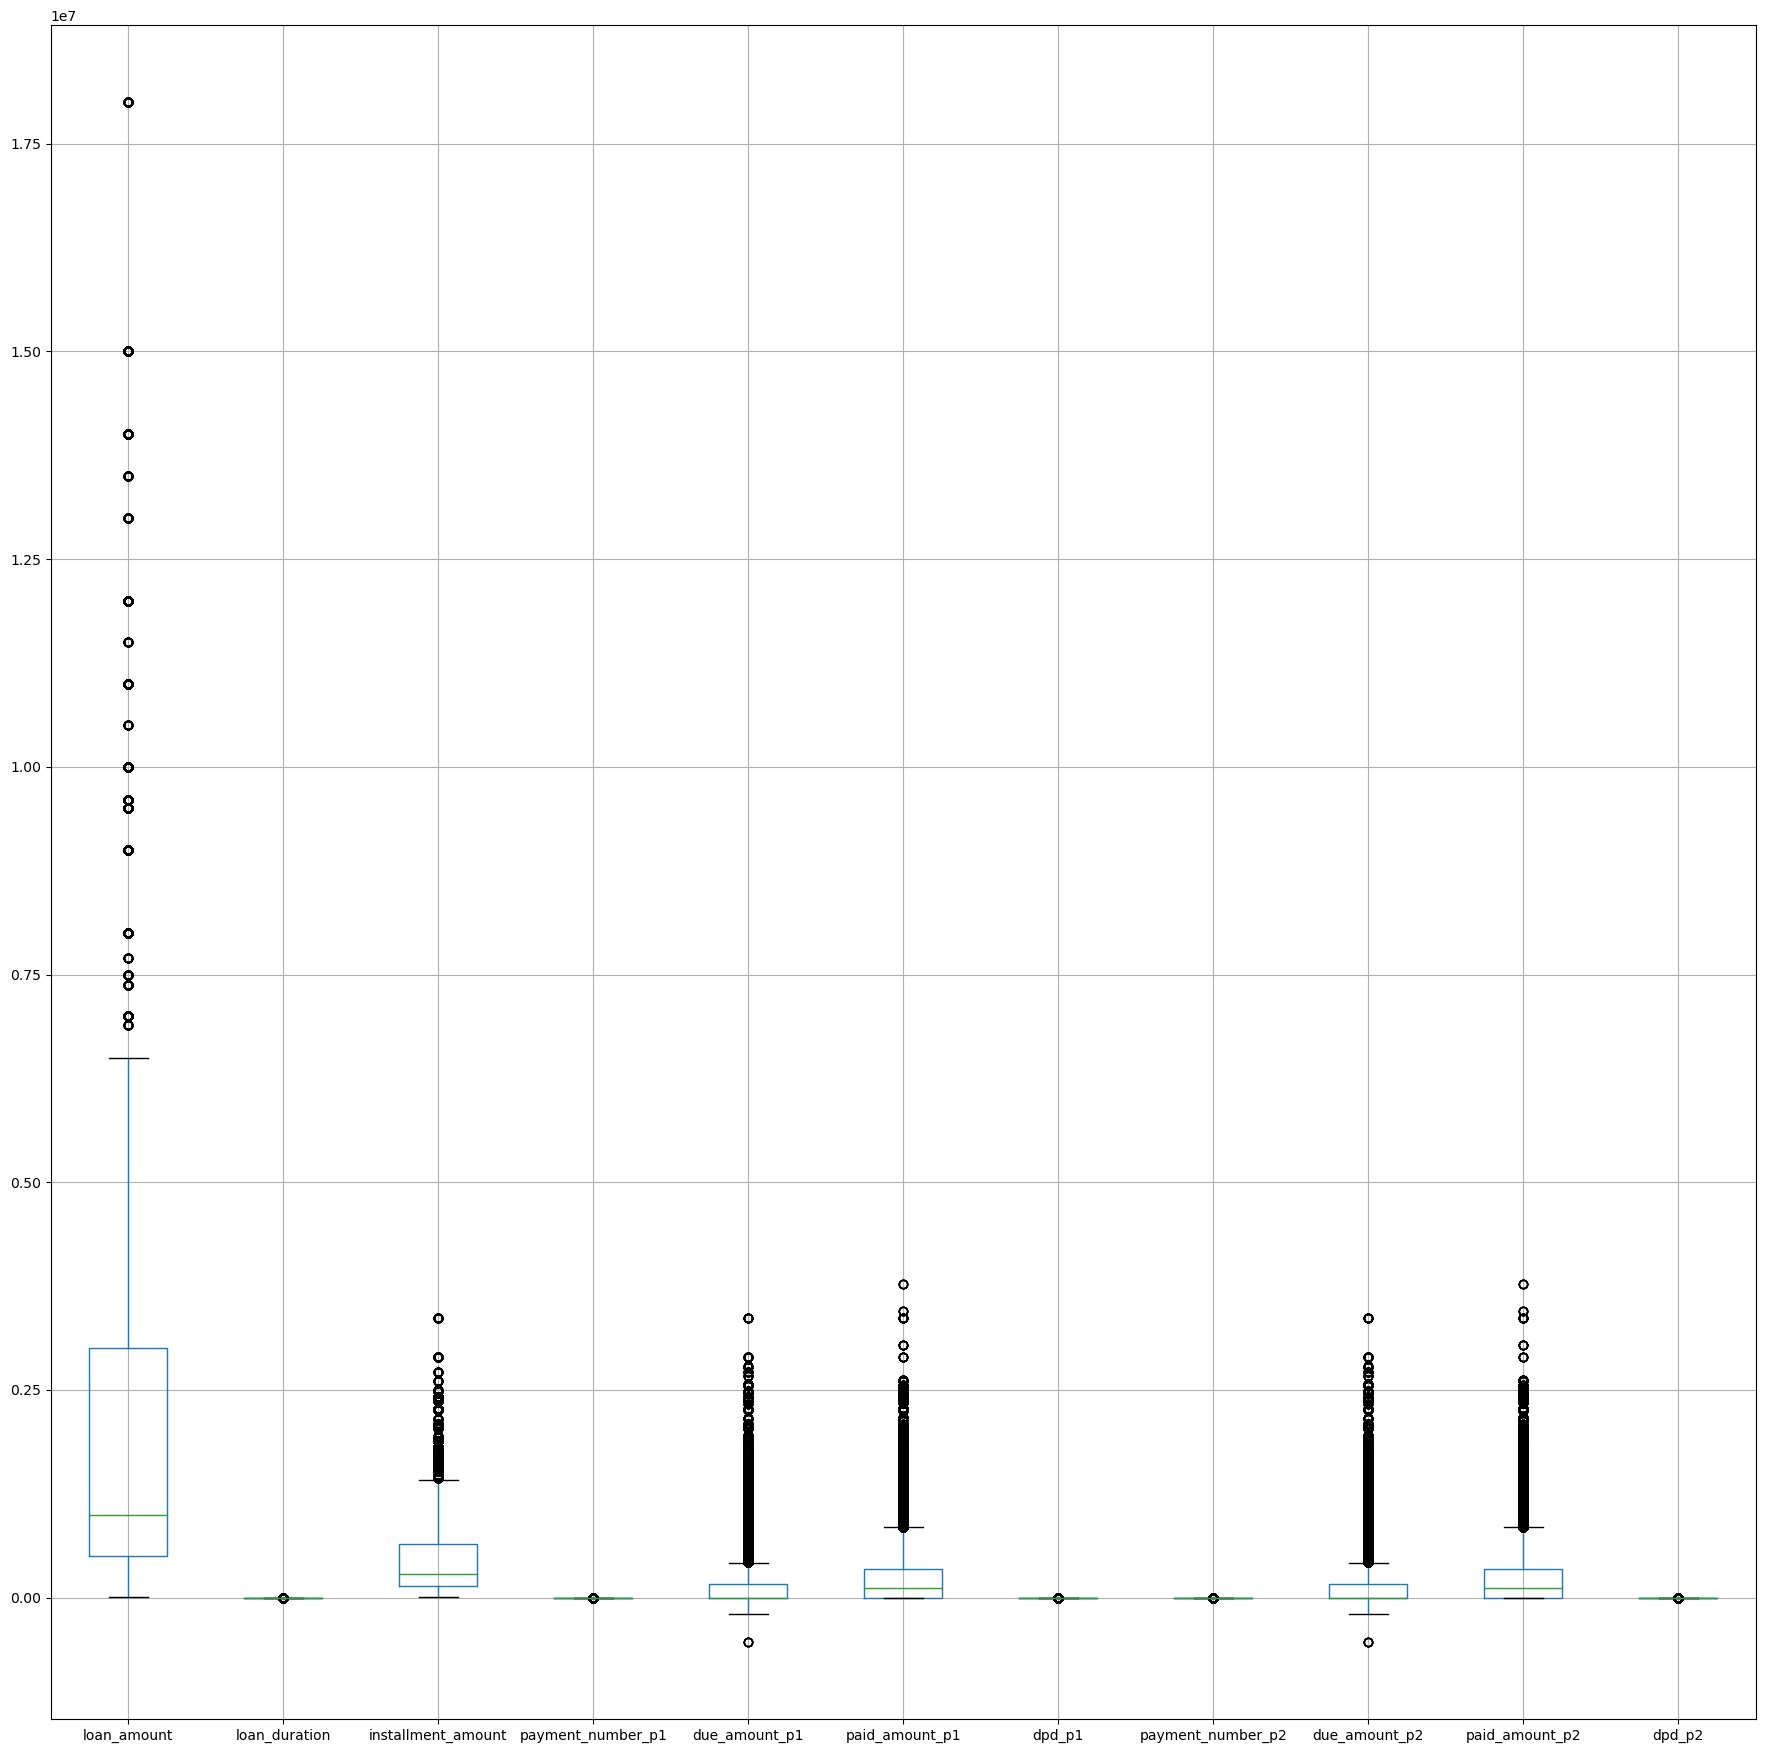

In [ ]:
import matplotlib.pyplot as plt

#Boxplot to preliminary check outliers
plt.figure(figsize=(22,22))
boxplot_data.boxplot()
plt.show()

Insight: from the boxplot above, all columns have outliers, unless loan_amount and loan_duration. But to make sure this assumption based on what we saw through data viz is correct, we'll check them using IQR method.

In [ ]:
df.dpd_p2.min()

-94.0

In [ ]:
df[df.dpd_p2 == -94]

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_date_p2,due_amount_p2,paid_date_p2,paid_amount_p2,dpd_p2
157,2021-04-23 00:37:57,2004026441562,2003023915519,Renovasi Rumah,untuk renopasi rumah .karna sebentar lagi leba...,1995-10-01,Banten,Menikah,0.0,Pegawai swasta,...,0.0,2021-06-01,828000.0,-94.0,4.0,2021-09-03,0.0,2021-06-01,828000.0,-94.0


In [ ]:
df.dpd_p1.unique()

array([ 44.,  74.,  27.,  33.,  28.,  30.,  29.,   0.,  26.,   8.,  31.,
        25.,  24.,   2.,  16., -35.,  20.,  49.,  57., -33.,  11.,  19.,
        32.,  22.,  23.,  45.,  -4., -94., -10.,  -2.,  21.,   7.,   1.,
        17.,   6.,  -5., -27.,  -7.,  -3.,  15., -22.,  67.,   5., -40.,
       -28.,  36., -30., -14.,  12., 182.,  -1.,  50.,  14., -32.,  18.,
        10.])

In [ ]:
df.dpd_p1.min()

-94.0

In [ ]:
df[df.dpd_p1 == -94]

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_date_p2,due_amount_p2,paid_date_p2,paid_amount_p2,dpd_p2
157,2021-04-23 00:37:57,2004026441562,2003023915519,Renovasi Rumah,untuk renopasi rumah .karna sebentar lagi leba...,1995-10-01,Banten,Menikah,0.0,Pegawai swasta,...,0.0,2021-06-01,828000.0,-94.0,4.0,2021-09-03,0.0,2021-06-01,828000.0,-94.0


In [ ]:
df.dpd_p1.max()

182.0

In [ ]:
df[df.dpd_p1 == 182]

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_date_p2,due_amount_p2,paid_date_p2,paid_amount_p2,dpd_p2
396,2021-02-23 07:24:14,2004025999506,2003023692629,Modal usaha,dalam masa pandemi ini tanaman hias menjadi pr...,1962-03-08,Jawa Barat,Menikah,3.0,Pegawai negeri,...,0.0,2021-09-26,283063.87186,182.0,1.0,2021-03-28,0.0,2021-09-26,283063.87186,182.0


In [ ]:
df.head()

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_date_p2,due_amount_p2,paid_date_p2,paid_amount_p2,dpd_p2
0,2021-01-07 13:45:43,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,2.0,2021-04-02,0.0,2021-05-16,195000.0,44.0
1,2021-01-14 15:56:27,2004025736661,2003023567116,Modal usaha,saya ingin menambah modal saya untuk berjualan...,1986-07-22,Banten,Menikah,2.0,Pegawai swasta,...,0.0,2021-05-14,219000.0,74.0,1.0,2021-03-01,0.0,2021-05-14,219000.0,74.0
2,2021-02-07 05:21:46,2004025885365,2003023442469,Kebutuhan sehari-hari,banyak pengeluaran bulan ini jadi ngk ketutup ...,NaT,None,Lajang,0.0,Pegawai swasta,...,0.0,2021-03-30,1885000.0,27.0,1.0,2021-03-03,0.0,2021-03-30,1885000.0,27.0
3,2021-04-22 07:15:09,2004026435734,2003023912156,Modal usaha,None,1996-01-16,Jawa Barat,Menikah,1.0,Pegawai swasta,...,0.0,2021-10-17,698000.0,33.0,1.0,2021-09-14,0.0,2021-10-17,698000.0,33.0
4,2021-02-07 14:57:21,2004025890269,2003023639117,Renovasi Rumah,Untuk renovasi rumah yg saat ini ada masalah p...,1992-06-13,None,None,0.0,Pegawai swasta,...,0.0,2021-05-27,1717000.0,28.0,1.0,2021-04-29,0.0,2021-05-27,1717000.0,28.0


### check missing values

In [ ]:
df.isna().sum().sort_values(ascending=False)

paid_date_p2          92
paid_date_p1          92
loan_purpose          53
job_type              52
address_provinsi      50
loan_purpose_desc     48
dependent             48
marital_status        46
job_industry          42
cdate                 40
dob                   40
due_date_p2           19
due_date_p1           19
fund_transfer_ts       5
payment_id             1
paid_amount_p2         0
due_amount_p2          0
payment_number_p2      0
dpd_p1                 0
paid_amount_p1         0
installment_amount     0
due_amount_p1          0
payment_number_p1      0
application_id         0
loan_duration          0
loan_amount            0
loan_id                0
customer_id            0
dpd_p2                 0
dtype: int64

In [ ]:
df.groupby('loan_purpose')['customer_id'].count()

loan_purpose
Belanja online                  2
Biaya kesehatan                23
Biaya liburan / umroh           4
Biaya pendidikan               50
Kebutuhan sehari-hari          75
Membayar hutang lainnya         9
Membeli elektronik             21
Membeli kendaraan               6
Modal usaha                   139
Renovasi Rumah                 66
Transfer ke Keluarga/Teman      3
Name: customer_id, dtype: int64

In [ ]:
df.groupby('job_type')['customer_id'].count()

job_type
Freelance             9
Ibu rumah tangga      4
Pegawai negeri       20
Pegawai swasta      343
Pengusaha            23
Name: customer_id, dtype: int64

In [ ]:
df.groupby('address_provinsi')['customer_id'].count()

address_provinsi
BANTEN                              3
Bali                               11
Banten                             49
Bengkulu                            1
DI Yogyakarta                       4
DKI JAKARTA                         2
DKI Jakarta                        80
Di Yogyakarta                       2
Dki Jakarta                        22
JAWA BARAT                          8
Jawa Barat                        129
Jawa Tengah                        20
Jawa Timur                         18
Kalimantan Barat                    2
Kalimantan Selatan                  3
Kalimantan Tengah                   1
Kalimantan Timur                    8
Kalimantan Utara                    1
Kepulauan Riau                      3
Lampung                             2
Maluku                              1
Nanggroe Aceh Darussalam (NAD)      1
Nanggroe Aceh Darussalam (nad)      2
Papua                               1
Riau                                3
Sulawesi Selatan                 

In [ ]:
#grouping Lower/Upper case province name into one category
df['address_provinsi'] = df['address_provinsi'].str.replace('JAWA BARAT', 'Jawa Barat')
df['address_provinsi'] = df['address_provinsi'].str.replace('BANTEN', 'Banten')
df['address_provinsi'] = df['address_provinsi'].str.replace('Di Yogyakarta', 'DI Yogyakarta')
df['address_provinsi'] = df['address_provinsi'].str.replace('DKI JAKARTA', 'DKI Jakarta')
df['address_provinsi'] = df['address_provinsi'].str.replace('Dki Jakarta', 'DKI Jakarta')
df['address_provinsi'] = df['address_provinsi'].str.replace('Nanggroe Aceh Darussalam (nad)', 'Nanggroe Aceh Darussalam (NAD)')


In [ ]:
df.groupby('address_provinsi')['customer_id'].count()

address_provinsi
Bali                               11
Banten                             52
Bengkulu                            1
DI Yogyakarta                       6
DKI Jakarta                       104
Jawa Barat                        137
Jawa Tengah                        20
Jawa Timur                         18
Kalimantan Barat                    2
Kalimantan Selatan                  3
Kalimantan Tengah                   1
Kalimantan Timur                    8
Kalimantan Utara                    1
Kepulauan Riau                      3
Lampung                             2
Maluku                              1
Nanggroe Aceh Darussalam (NAD)      3
Papua                               1
Riau                                3
Sulawesi Selatan                    5
Sulawesi Tenggara                   1
Sulawesi Utara                      3
Sumatera Barat                      4
Sumatera Selatan                    2
Sumatera Utara                      9
Name: customer_id, dtype: int64

In [ ]:
df.groupby('loan_purpose_desc')['customer_id'].count()

loan_purpose_desc
Belikan spandek,untuk buat atap rumah,karena sudah pada rusak.                     1
Biaya bayar kuliah anak dan praktek lapangan ke ciwidey                            1
Biaya pasang teralis rumah dan kanopi depan rumah                                  1
Biaya untuk anak melanjutkan sekolah ke Sekolah Menengah Atas                      1
Buat Liburan Ke Pangandaran Bareng Keluarga                                        1
                                                                                  ..
untuk tambahan nikah, dan kebutuhan sehari hari kedepannya                         1
untuk tambahan pembelian barang yang diinginkan                                    1
untuk usaha membuat makanan / camilan / kue                                        1
untul menambah modal usaha kue yang saya jalankan saat ini sya kekurangan modal    1
usaha kecil kecil kreditin barang elektronik                                       1
Name: customer_id, Length: 402, dtype: int64

In [ ]:
df.groupby('dependent')['customer_id'].count()

dependent
0.0    148
1.0    107
2.0     91
3.0     46
4.0      9
5.0      2
Name: customer_id, dtype: int64

In [ ]:
df.groupby('marital_status')['customer_id'].count()

marital_status
Cerai            10
Janda / duda      3
Lajang          145
Menikah         247
Name: customer_id, dtype: int64

In [ ]:
#grouping Janda/duda into Cerai, suppose this value is similar
df['marital_status'] = df['marital_status'].str.replace('Janda / duda', 'Cerai')


In [ ]:
df.groupby('marital_status')['customer_id'].count()

marital_status
Cerai       13
Lajang     145
Menikah    247
Name: customer_id, dtype: int64

In [ ]:
df.groupby('job_industry')['customer_id'].count()

job_industry
Admin / Finance / HR          68
Design / Seni                  2
Entertainment / Event          7
Hukum / Security / Politik    11
Kesehatan                     26
Konstruksi / Real Estate      26
Pabrik / Gudang               80
Pendidikan                    20
Perawatan Tubuh                2
Perbankan                     18
Perhotelan                     6
Sales / Marketing             66
Service                       37
Staf Rumah Tangga              3
Tehnik / Computer             21
Transportasi                  16
Name: customer_id, dtype: int64

In [ ]:
#handling missing value by fillna with mode bc of categorical feature
df.loan_purpose = df.loan_purpose.fillna(df.loan_purpose.mode()[0])
df.job_type = df.job_type.fillna(df.job_type.mode()[0])
df.address_provinsi = df.address_provinsi.fillna(df.address_provinsi.mode()[0])
df.loan_purpose_desc = df.loan_purpose_desc.fillna(df.loan_purpose_desc.mode()[0])
df.dependent = df.dependent.fillna(df.dependent.mode()[0])
df.marital_status = df.marital_status.fillna(df.marital_status.mode()[0])
df.job_industry = df.job_industry.fillna(df.job_industry.mode()[0])

In [ ]:
#check na again
df.isnull().sum()

cdate                 40
application_id         0
customer_id            0
loan_purpose           0
loan_purpose_desc      0
dob                   40
address_provinsi       0
marital_status         0
dependent              0
job_type               0
job_industry           0
loan_id                0
loan_amount            0
loan_duration          0
installment_amount     0
fund_transfer_ts       5
payment_id             1
payment_number_p1      0
due_date_p1           19
due_amount_p1          0
paid_date_p1          92
paid_amount_p1         0
dpd_p1                 0
payment_number_p2      0
due_date_p2           19
due_amount_p2          0
paid_date_p2          92
paid_amount_p2         0
dpd_p2                 0
dtype: int64

### unnecessary columns/rows

In [ ]:
df.nunique()

cdate                 411
application_id        451
customer_id           451
loan_purpose           11
loan_purpose_desc     402
dob                   399
address_provinsi       25
marital_status          3
dependent               6
job_type                5
job_industry           16
loan_id               451
loan_amount            97
loan_duration           9
installment_amount    210
fund_transfer_ts      446
payment_id            450
payment_number_p1       9
due_date_p1           185
due_amount_p1          76
paid_date_p1          196
paid_amount_p1        259
dpd_p1                 56
payment_number_p2       9
due_date_p2           185
due_amount_p2          76
paid_date_p2          196
paid_amount_p2        259
dpd_p2                 56
dtype: int64

### checking duplicates data

In [ ]:
#Check duplicate values
df[df.duplicated(keep=False)]

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_date_p2,due_amount_p2,paid_date_p2,paid_amount_p2,dpd_p2


There's no duplicate data.

### checking outliers

In [ ]:
#Statistic Descriptive
df[continuous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amount,451.0,2.170995e+06,2.730785e+06,10453.0,500000.0,1000000.0,3000000.0,18000000.0
loan_duration,451.0,4.594235e+00,2.192282e+00,1.0,3.0,5.0,6.0,9.0
installment_amount,451.0,5.142991e+05,5.348045e+05,11355.0,124000.0,290000.0,710000.0,2900000.0
payment_number_p1,451.0,2.186253e+00,1.466935e+00,1.0,1.0,2.0,3.0,9.0
due_amount_p1,451.0,9.244638e+04,3.096405e+05,0.0,0.0,0.0,0.0,2900000.0
paid_amount_p1,451.0,4.255293e+05,5.171720e+05,0.0,55701.0,206000.0,632000.0,2625000.0
dpd_p1,451.0,1.802882e+01,1.813644e+01,-94.0,0.0,26.0,29.0,182.0
payment_number_p2,451.0,2.186253e+00,1.466935e+00,1.0,1.0,2.0,3.0,9.0
due_amount_p2,451.0,9.244638e+04,3.096405e+05,0.0,0.0,0.0,0.0,2900000.0
paid_amount_p2,451.0,4.255293e+05,5.171720e+05,0.0,55701.0,206000.0,632000.0,2625000.0


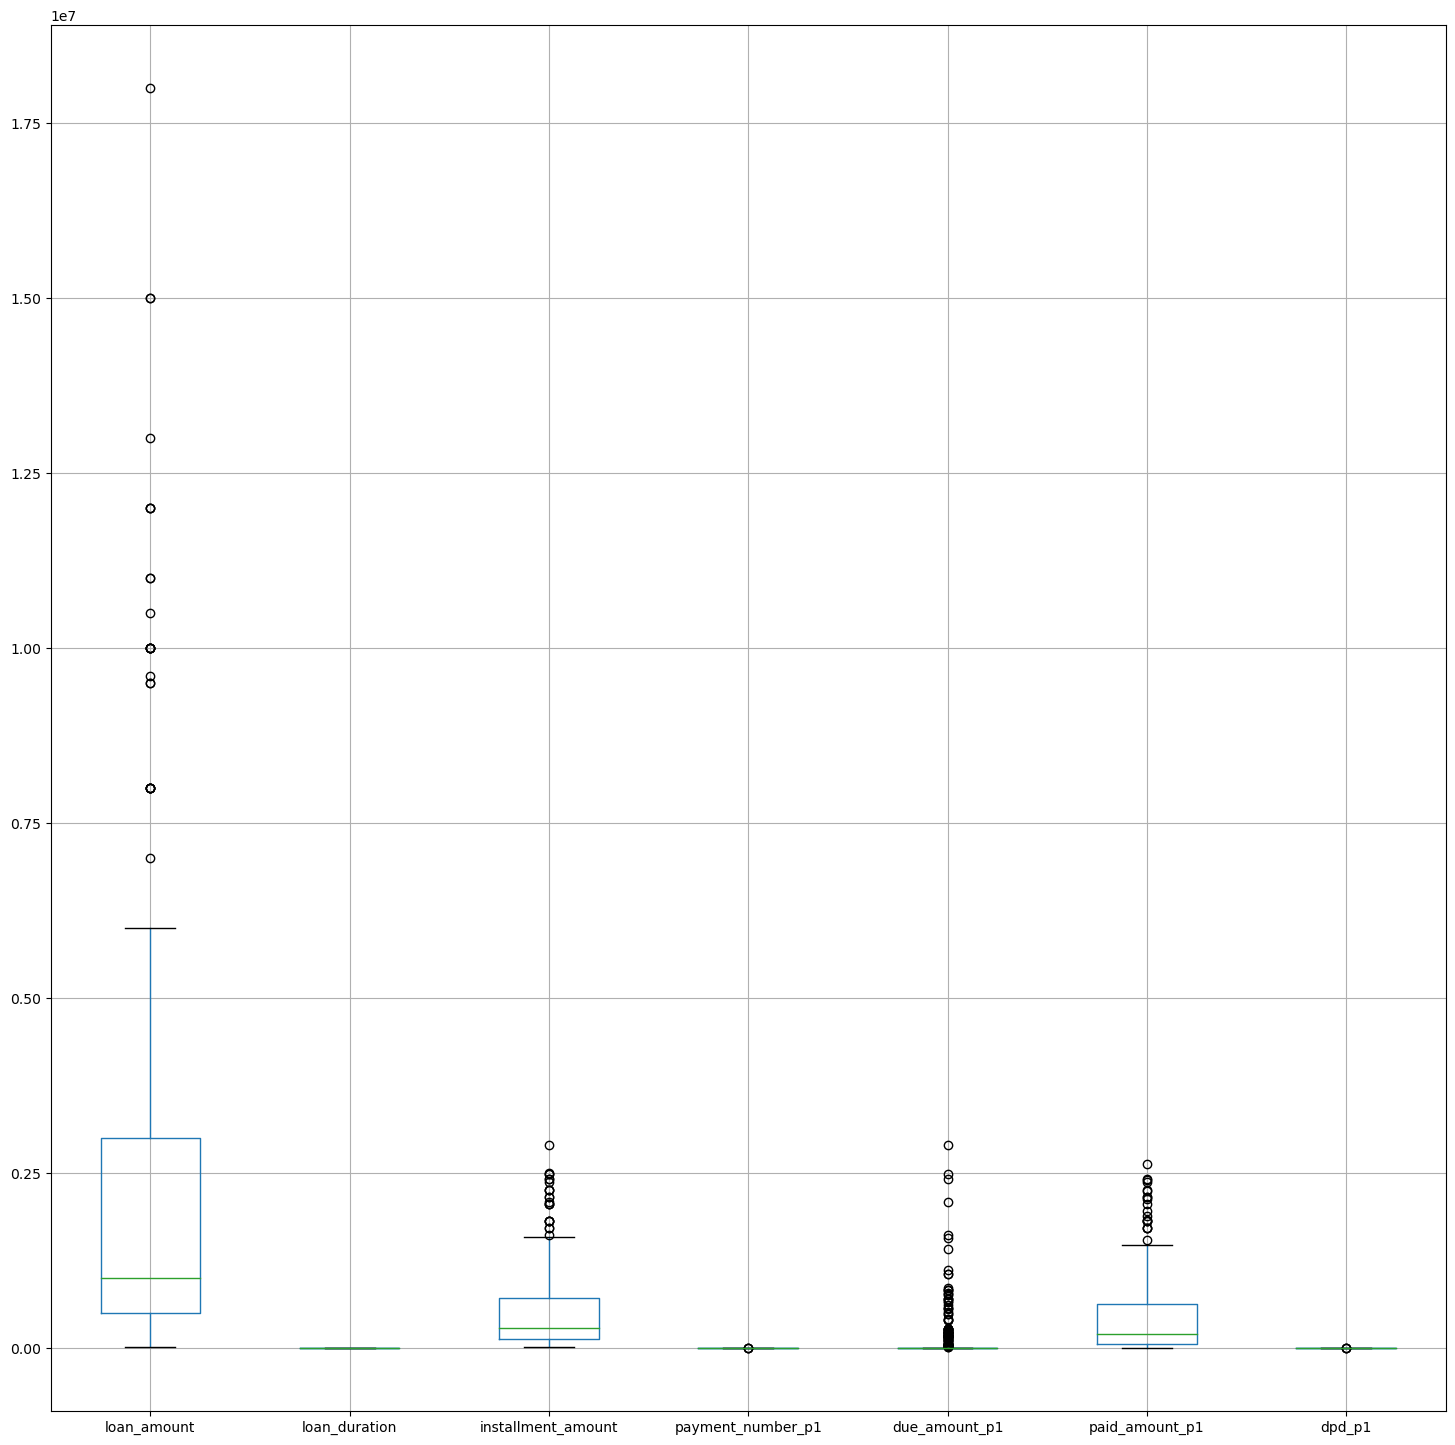

In [ ]:
#Boxplot
plt.figure(figsize=(18,18))
df[["loan_amount","loan_duration","installment_amount","payment_number_p1","due_amount_p1","paid_amount_p1","dpd_p1"]].boxplot()
plt.show()

In [ ]:
def outliers_graph(df_column):
    Q75, Q25 = np.percentile(df_column, [75 ,25])
    IQR = Q75 - Q25
    print('Q25: ',Q25)
    print('Q75: ',Q75)
    print('Inter Quartile Range: ',IQR)
    print('Outliers lie before', Q25-1.5*IQR, 'and beyond', Q75+1.5*IQR)
    print('Number of Rows with Left Extreme Outliers:', len(df[df_column <Q25-1.5*IQR]))
    print('Number of Rows with Right Extreme Outliers:', len(df[df_column>Q75+1.5*IQR]))

In [ ]:
outliers_graph(df['loan_amount'])

Q25:  500000.0
Q75:  3000000.0
Inter Quartile Range:  2500000.0
Outliers lie before -3250000.0 and beyond 6750000.0
Number of Rows with Left Extreme Outliers: 0
Number of Rows with Right Extreme Outliers: 26


#### Insight:
There are 26 major outliers and it will be handling by dropping them.

In [ ]:
df1 = df[~((df['loan_amount'] < -3250000.0) | (df['loan_amount'] > 6750000.0))]

In [ ]:
outliers_graph(df["loan_duration"])

Q25:  3.0
Q75:  6.0
Inter Quartile Range:  3.0
Outliers lie before -1.5 and beyond 10.5
Number of Rows with Left Extreme Outliers: 0
Number of Rows with Right Extreme Outliers: 0


#### Insight:
There is no outlier.

In [ ]:
outliers_graph(df["installment_amount"])

Q25:  124000.0
Q75:  710000.0
Inter Quartile Range:  586000.0
Outliers lie before -755000.0 and beyond 1589000.0
Number of Rows with Left Extreme Outliers: 0
Number of Rows with Right Extreme Outliers: 23


#### Insight:
There are 23 major outliers and it will be handling by dropping them.

In [ ]:
df1 = df1[~((df1['installment_amount'] < -755000.0) | (df1['installment_amount'] > 1589000.0))]

In [ ]:
outliers_graph(df["payment_number_p1"])

Q25:  1.0
Q75:  3.0
Inter Quartile Range:  2.0
Outliers lie before -2.0 and beyond 6.0
Number of Rows with Left Extreme Outliers: 0
Number of Rows with Right Extreme Outliers: 3


#### Insight:
There are 3 major outliers and it will be handling by dropping them.

In [ ]:
df1 = df1[~((df1['payment_number_p1'] < -2.0) | (df1['payment_number_p1'] > 6.0))]

In [ ]:
outliers_graph(df["due_amount_p1"])

Q25:  0.0
Q75:  0.0
Inter Quartile Range:  0.0
Outliers lie before 0.0 and beyond 0.0
Number of Rows with Left Extreme Outliers: 0
Number of Rows with Right Extreme Outliers: 95


#### Insight:
There are 95 major outliers and it will be handling by dropping them.

In [ ]:
df1 = df1[~((df1['due_amount_p1'] < 0) | (df1['due_amount_p1'] > 0))]

In [ ]:
outliers_graph(df["paid_amount_p1"])

Q25:  55701.0
Q75:  632000.0
Inter Quartile Range:  576299.0
Outliers lie before -808747.5 and beyond 1496448.5
Number of Rows with Left Extreme Outliers: 0
Number of Rows with Right Extreme Outliers: 20


#### Insight:
There are 20 major outliers and it will be handling by dropping them.

In [ ]:
df1 = df1[~((df1['paid_amount_p1'] < -808747.5) | (df1['paid_amount_p1'] > 1496448.5))]

In [ ]:
outliers_graph(df["dpd_p1"])

Q25:  0.0
Q75:  29.0
Inter Quartile Range:  29.0
Outliers lie before -43.5 and beyond 72.5
Number of Rows with Left Extreme Outliers: 1
Number of Rows with Right Extreme Outliers: 2


#### Insight:
There are 2 major outlier and 1 minor oultiers and it will be handling by dropping them.

In [ ]:
df1 = df1[~((df1['dpd_p1'] < -43.5) | (df1['dpd_p1'] > 72.5))]

In [ ]:
df1

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_date_p2,due_amount_p2,paid_date_p2,paid_amount_p2,dpd_p2
0,2021-01-07 13:45:43,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,0.0,2021-05-16,195000.0,44.0,2.0,2021-04-02,0.0,2021-05-16,195000.0,44.0
3,2021-04-22 07:15:09,2004026435734,2003023912156,Modal usaha,renovasi rumah perbaikan atap rumah bocor,1996-01-16,Jawa Barat,Menikah,1.0,Pegawai swasta,...,0.0,2021-10-17,698000.0,33.0,1.0,2021-09-14,0.0,2021-10-17,698000.0,33.0
5,2021-05-12 06:17:10,2004026582292,2003023805529,Kebutuhan sehari-hari,renovasi rumah perbaikan atap rumah bocor,1984-04-24,Jawa Barat,Menikah,1.0,Pegawai swasta,...,0.0,2021-07-11,78000.0,30.0,1.0,2021-06-11,0.0,2021-07-11,78000.0,30.0
6,2021-01-09 08:56:42,2004025703643,2003021445342,Renovasi Rumah,untuk merenovasi rumah yang saya tempati,1983-03-26,Jawa Barat,Menikah,2.0,Pegawai swasta,...,0.0,2021-04-15,355000.0,29.0,2.0,2021-03-17,0.0,2021-04-15,355000.0,29.0
8,2021-01-10 08:38:49,2004025708676,2003022313019,Biaya pendidikan,"Menunjang belajar online berupa komputer, mode...",1974-11-03,Banten,Menikah,3.0,Pegawai swasta,...,0.0,2021-08-27,300000.0,26.0,4.0,2021-08-01,0.0,2021-08-27,300000.0,26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,2021-04-02 09:59:06,2004026283775,2003023835969,Renovasi Rumah,renovasi rumah perbaikan atap rumah bocor,1982-10-12,DKI Jakarta,Menikah,1.0,Pegawai swasta,...,0.0,2021-10-22,1065000.0,10.0,6.0,2021-10-12,0.0,2021-10-22,1065000.0,10.0
447,2021-05-06 04:04:23,2004026541054,2003023971833,Kebutuhan sehari-hari,renovasi rumah perbaikan atap rumah bocor,1994-02-05,Jawa Barat,Menikah,0.0,Pegawai swasta,...,0.0,2021-08-25,620000.0,26.0,3.0,2021-07-30,0.0,2021-08-25,620000.0,26.0
448,2021-06-09 02:39:48,2004026770549,2003023874771,Kebutuhan sehari-hari,selamat pagi julo saya mengajukan limit julo k...,1992-04-11,Jawa Barat,Menikah,0.0,Pegawai swasta,...,0.0,2022-03-07,306000.0,26.0,1.0,2022-02-09,0.0,2022-03-07,306000.0,26.0
449,2021-03-11 03:39:05,2004026118497,2003023752181,Biaya kesehatan,untuk biaya kesehatan orang tua dan membeli ob...,1999-10-29,Jawa Barat,Lajang,0.0,Pegawai swasta,...,0.0,2022-01-04,85000.0,30.0,2.0,2021-12-05,0.0,2022-01-04,85000.0,30.0


In [ ]:
#check na, all columns are clear
df1.isnull().sum()

cdate                 25
application_id         0
customer_id            0
loan_purpose           0
loan_purpose_desc      0
dob                   31
address_provinsi       0
marital_status         0
dependent              0
job_type               0
job_industry           0
loan_id                0
loan_amount            0
loan_duration          0
installment_amount     0
fund_transfer_ts       4
payment_id             0
payment_number_p1      0
due_date_p1           13
due_amount_p1          0
paid_date_p1           6
paid_amount_p1         0
dpd_p1                 0
payment_number_p2      0
due_date_p2           13
due_amount_p2          0
paid_date_p2           6
paid_amount_p2         0
dpd_p2                 0
dtype: int64

### Assignment 2 - Label analysis

Please do all these analysis in SQL query.
1. We don't want to give credit to `bad` customers (customers that don't pay at all). Can you define what a `bad` customers is from the dataset provided and what is the earliest indicator to say that a customer is `bad`?
2. Based on the label that you defined, what kind of trends do you see in the data that distinguish good and bad customers?
3. Arrange customers by “loan amount” in ascending order and provide cumulative default rates by equal-sized deciles. Each decile should have:
> a. Number of loans <br>
> b. Number of defaulted loans <br>
> c. The default rate for each decile <br>
> d. Cumulative default rate <br>
> e. Min, max, avg “loan amount” <br>

#### 2.1 Bad Customers Definition

Since there was no metadata or data description, I assume that negative value in dpd feature is early a credit payment. Days Past Due (DPD) itself indicates the number of days by which a borrower has missed a credit payment. Bad customers definition within the 30 days they has missed a credit payment. Hence, it's the earliest indicator to say that a customer is bad.

In [ ]:
# Insert last df from pd.DataFrame to SQL Alchemy Engine
df1.to_sql(name='df_cust', con=engine,if_exists='replace')

330

In [ ]:
query_from_db('''SELECT customer_id, dpd_p1,
                 CASE
                 WHEN dpd_p1 > 30 THEN "bad"
                 ELSE "good"
                 END AS customer_stat
                 FROM df_cust''', engine)


,customer_id,dpd_p1,customer_stat
0,2003023548799,44.0,bad
1,2003023912156,33.0,bad
2,2003023805529,30.0,good
3,2003021445342,29.0,good
4,2003022313019,26.0,good
...,...,...,...
325,2003023835969,10.0,good
326,2003023971833,26.0,good
327,2003023874771,26.0,good
328,2003023752181,30.0,good


In [ ]:
query_from_db('''SELECT COUNT(customer_id),
                 CASE
                 WHEN dpd_p1 > 30 THEN "bad"
                 ELSE "good"
                 END AS customer_stat
                 FROM df_cust
                 GROUP BY customer_stat;''', engine)

,COUNT(customer_id),customer_stat
0,17,bad
1,313,good


In [ ]:
df2 = query_from_db('''SELECT *,
                 CASE
                 WHEN dpd_p1 > 30 THEN "bad"
                 ELSE "good"
                 END AS customer_stat
                 FROM df_cust''', engine)

In [ ]:
df2.head()

,index,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,...,paid_date_p1,paid_amount_p1,dpd_p1,payment_number_p2,due_date_p2,due_amount_p2,paid_date_p2,paid_amount_p2,dpd_p2,customer_stat
0,0,2021-01-07 13:45:43.000000,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06 00:00:00.000000,Banten,Lajang,1.0,...,2021-05-16 00:00:00.000000,195000.0,44.0,2.0,2021-04-02 00:00:00.000000,0.0,2021-05-16 00:00:00.000000,195000.0,44.0,bad
1,3,2021-04-22 07:15:09.000000,2004026435734,2003023912156,Modal usaha,renovasi rumah perbaikan atap rumah bocor,1996-01-16 00:00:00.000000,Jawa Barat,Menikah,1.0,...,2021-10-17 00:00:00.000000,698000.0,33.0,1.0,2021-09-14 00:00:00.000000,0.0,2021-10-17 00:00:00.000000,698000.0,33.0,bad
2,5,2021-05-12 06:17:10.000000,2004026582292,2003023805529,Kebutuhan sehari-hari,renovasi rumah perbaikan atap rumah bocor,1984-04-24 00:00:00.000000,Jawa Barat,Menikah,1.0,...,2021-07-11 00:00:00.000000,78000.0,30.0,1.0,2021-06-11 00:00:00.000000,0.0,2021-07-11 00:00:00.000000,78000.0,30.0,good
3,6,2021-01-09 08:56:42.000000,2004025703643,2003021445342,Renovasi Rumah,untuk merenovasi rumah yang saya tempati,1983-03-26 00:00:00.000000,Jawa Barat,Menikah,2.0,...,2021-04-15 00:00:00.000000,355000.0,29.0,2.0,2021-03-17 00:00:00.000000,0.0,2021-04-15 00:00:00.000000,355000.0,29.0,good
4,8,2021-01-10 08:38:49.000000,2004025708676,2003022313019,Biaya pendidikan,"Menunjang belajar online berupa komputer, mode...",1974-11-03 00:00:00.000000,Banten,Menikah,3.0,...,2021-08-27 00:00:00.000000,300000.0,26.0,4.0,2021-08-01 00:00:00.000000,0.0,2021-08-27 00:00:00.000000,300000.0,26.0,good


In [ ]:
#we assume payment1 = payment2 and we decided to use features in payment1
df2 = df2.drop(columns=["payment_number_p2","due_date_p2","due_amount_p2","paid_date_p2","paid_amount_p2","dpd_p2"], axis=1)

In [ ]:
df2.head()

,index,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,...,installment_amount,fund_transfer_ts,payment_id,payment_number_p1,due_date_p1,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,customer_stat
0,0,2021-01-07 13:45:43.000000,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06 00:00:00.000000,Banten,Lajang,1.0,...,140000.0,2021-01-24 12:17:45,2.006022e+12,2.0,2021-04-02 00:00:00.000000,0.0,2021-05-16 00:00:00.000000,195000.0,44.0,bad
1,3,2021-04-22 07:15:09.000000,2004026435734,2003023912156,Modal usaha,renovasi rumah perbaikan atap rumah bocor,1996-01-16 00:00:00.000000,Jawa Barat,Menikah,1.0,...,680000.0,2021-08-12 03:28:14,2.006023e+12,1.0,2021-09-14 00:00:00.000000,0.0,2021-10-17 00:00:00.000000,698000.0,33.0,bad
2,5,2021-05-12 06:17:10.000000,2004026582292,2003023805529,Kebutuhan sehari-hari,renovasi rumah perbaikan atap rumah bocor,1984-04-24 00:00:00.000000,Jawa Barat,Menikah,1.0,...,82000.0,2021-05-23 13:31:06,2.006023e+12,1.0,2021-06-11 00:00:00.000000,0.0,2021-07-11 00:00:00.000000,78000.0,30.0,good
3,6,2021-01-09 08:56:42.000000,2004025703643,2003021445342,Renovasi Rumah,untuk merenovasi rumah yang saya tempati,1983-03-26 00:00:00.000000,Jawa Barat,Menikah,2.0,...,355000.0,2021-01-09 09:45:45,2.006022e+12,2.0,2021-03-17 00:00:00.000000,0.0,2021-04-15 00:00:00.000000,355000.0,29.0,good
4,8,2021-01-10 08:38:49.000000,2004025708676,2003022313019,Biaya pendidikan,"Menunjang belajar online berupa komputer, mode...",1974-11-03 00:00:00.000000,Banten,Menikah,3.0,...,300000.0,2021-04-14 09:52:32,2.006022e+12,4.0,2021-08-01 00:00:00.000000,0.0,2021-08-27 00:00:00.000000,300000.0,26.0,good


In [ ]:
df2.shape

(330, 25)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               330 non-null    int64  
 1   cdate               305 non-null    object 
 2   application_id      330 non-null    int64  
 3   customer_id         330 non-null    int64  
 4   loan_purpose        330 non-null    object 
 5   loan_purpose_desc   330 non-null    object 
 6   dob                 299 non-null    object 
 7   address_provinsi    330 non-null    object 
 8   marital_status      330 non-null    object 
 9   dependent           330 non-null    float64
 10  job_type            330 non-null    object 
 11  job_industry        330 non-null    object 
 12  loan_id             330 non-null    int64  
 13  loan_amount         330 non-null    float64
 14  loan_duration       330 non-null    float64
 15  installment_amount  330 non-null    float64
 16  fund_tra

In [ ]:
df2.cdate = pd.to_datetime(df2.cdate, errors='coerce', utc=True).dt.strftime('%Y-%m-%d %X').astype('datetime64[ns]')
df2.fund_transfer_ts = pd.to_datetime(df2.fund_transfer_ts, errors='coerce', utc=True).dt.strftime('%Y-%m-%d %X').astype('datetime64[ns]')
df2.due_date_p1 = pd.to_datetime(df2.due_date_p1, errors='coerce', utc=True).dt.strftime('%Y-%m-%d').astype('datetime64[ns]')
df2.paid_date_p1 = pd.to_datetime(df2.paid_date_p1, errors='coerce', utc=True).dt.strftime('%Y-%m-%d').astype('datetime64[ns]')
df2.dob = pd.to_datetime(df2.dob, errors='coerce', utc=True).dt.strftime('%Y-%m-%d').astype('datetime64[ns]')

In [ ]:
 cust_indicator = query_from_db('''WITH CustomerBadIndicator AS (
  SELECT
    customer_id,
    MIN(dpd_p1) AS earliest_indicator
  FROM
    df_cust
  WHERE
    dpd_p1 > 30  -- Define the threshold for bad customers
  GROUP BY
    customer_id)


SELECT
  c.customer_id,
  c.cdate AS customer_creation_date,
  c.dob AS customer_date_of_birth,
  c.address_provinsi AS customer_province,
  c.marital_status AS customer_marital_status,
  c.dependent AS customer_dependents,
  c.job_type AS customer_job_type,
  c.job_industry AS customer_job_industry,
  cb.earliest_indicator AS earliest_indicator_dpd
FROM
 df_cust c
LEFT JOIN
  CustomerBadIndicator cb ON c.customer_id = cb.customer_id''', engine)

cust_indicator.head()

,customer_id,customer_creation_date,customer_date_of_birth,customer_province,customer_marital_status,customer_dependents,customer_job_type,customer_job_industry,earliest_indicator_dpd
0,2003023548799,2021-01-07 13:45:43.000000,2000-01-06 00:00:00.000000,Banten,Lajang,1.0,Pegawai swasta,Admin / Finance / HR,44.0
1,2003023912156,2021-04-22 07:15:09.000000,1996-01-16 00:00:00.000000,Jawa Barat,Menikah,1.0,Pegawai swasta,Pabrik / Gudang,33.0
2,2003023805529,2021-05-12 06:17:10.000000,1984-04-24 00:00:00.000000,Jawa Barat,Menikah,1.0,Pegawai swasta,Service,NaN
3,2003021445342,2021-01-09 08:56:42.000000,1983-03-26 00:00:00.000000,Jawa Barat,Menikah,2.0,Pegawai swasta,Entertainment / Event,NaN
4,2003022313019,2021-01-10 08:38:49.000000,1974-11-03 00:00:00.000000,Banten,Menikah,3.0,Pegawai swasta,Pabrik / Gudang,NaN


In [ ]:
cust_indicator.earliest_indicator_dpd.unique()

array([44., 33., nan, 31., 49., 57., 32., 67., 50.])

In [ ]:
#count of good customers
cust_indicator.earliest_indicator_dpd.isnull().sum()

313

In [ ]:
cust_indicator.to_sql(name='cust_status', con=engine,if_exists='replace')

330

In [ ]:
target = query_from_db('''SELECT *,
                 CASE
                 WHEN earliest_indicator_dpd > 30 THEN "bad"
                 ELSE "good"
                 END AS customer_stat
                 FROM cust_status''', engine)

In [ ]:
target.head()

,index,customer_id,customer_creation_date,customer_date_of_birth,customer_province,customer_marital_status,customer_dependents,customer_job_type,customer_job_industry,earliest_indicator_dpd,customer_stat
0,0,2003023548799,2021-01-07 13:45:43.000000,2000-01-06 00:00:00.000000,Banten,Lajang,1.0,Pegawai swasta,Admin / Finance / HR,44.0,bad
1,1,2003023912156,2021-04-22 07:15:09.000000,1996-01-16 00:00:00.000000,Jawa Barat,Menikah,1.0,Pegawai swasta,Pabrik / Gudang,33.0,bad
2,2,2003023805529,2021-05-12 06:17:10.000000,1984-04-24 00:00:00.000000,Jawa Barat,Menikah,1.0,Pegawai swasta,Service,NaN,good
3,3,2003021445342,2021-01-09 08:56:42.000000,1983-03-26 00:00:00.000000,Jawa Barat,Menikah,2.0,Pegawai swasta,Entertainment / Event,NaN,good
4,4,2003022313019,2021-01-10 08:38:49.000000,1974-11-03 00:00:00.000000,Banten,Menikah,3.0,Pegawai swasta,Pabrik / Gudang,NaN,good


In [ ]:
target.groupby('customer_stat')['customer_id'].count()

customer_stat
bad      17
good    313
Name: customer_id, dtype: int64

#### 2.2 Pattern & Trend of Data

To distinguish between good and bad customers, we can observe several trends and patterns in the data:

1. **Age**: Check if there's any age trend that distinguishes good and bad customers. For example, do bad customers tend to be younger or older than good customers?

2. **Marital Status**: Analyze if there's a correlation between marital status and being a bad customer. Do single or divorced customers have a higher likelihood of being bad customers?

3. **Dependents**: Investigate if the number of dependents has any impact. Do customers with more dependents tend to be better or worse in terms of repayment behavior?

4. **Job Type and Industry**: Examine if the type of job and industry have an influence. Are customers in certain job types or industries more likely to default on loans?

5. **Location (Province)**: Check if the province where customers live plays a role. Are customers from specific provinces more likely to be bad customers?

6. **Earliest Indicator (DPD)**: Understand how the earliest indicator of being a bad customer (DPD > 30) relates to other factors. Does a high DPD value correlate with other negative trends, such as younger age or specific job types?

7. **Customer Creation Date**: Analyze if there's any trend over time. Do more recent customers tend to be better or worse than older customers in terms of loan repayment?

By exploring these trends and patterns in the data, we can gain insights into the characteristics and behaviors that distinguish good customers from bad ones. Machine learning models can be trained on these features to predict credit risk and identify potential bad customers based on these patterns. It's important to note that the above trends are general indicators, and a comprehensive analysis may involve more advanced statistical and machine learning techniques to identify predictive factors accurately.

In [ ]:
query_from_db('''SELECT
  customer_marital_status,
  SUM(CASE WHEN earliest_indicator_dpd IS NOT NULL THEN 1 ELSE 0 END) AS num_bad_customers,
  SUM(CASE WHEN earliest_indicator_dpd IS NULL THEN 1 ELSE 0 END) AS num_good_customers
FROM
  cust_status
GROUP BY
  customer_marital_status''', engine)

,customer_marital_status,num_bad_customers,num_good_customers
0,Cerai,0,11
1,Lajang,5,104
2,Menikah,12,198


#### Insight:
 Married customers have a higher likelihood of being bad customers than single or divorce customers.

In [ ]:
query_from_db('''SELECT
  a.customer_dependents,
  SUM(CASE WHEN b.dpd_p1 > 30 THEN 1 ELSE 0 END) AS num_customers_dpd_gt_30
FROM
 df_cust b
LEFT JOIN
  cust_status a ON a.customer_id = b.customer_id
GROUP BY
  a.customer_dependents;''', engine)


,customer_dependents,num_customers_dpd_gt_30
0,0.0,6
1,1.0,7
2,2.0,2
3,3.0,2
4,4.0,0
5,5.0,0


#### Insight:
Customers with more dependents tend to be worse in terms of repayment behavior.

In [ ]:
query_from_db('''SELECT
  a.customer_job_type,
  SUM(CASE WHEN b.dpd_p1 > 30 THEN 1 ELSE 0 END) AS num_customers_dpd_gt_30
FROM
 df_cust b
LEFT JOIN
  cust_status a ON a.customer_id = b.customer_id
GROUP BY
  a.customer_job_type
ORDER BY
  num_customers_dpd_gt_30 DESC;''', engine)

,customer_job_type,num_customers_dpd_gt_30
0,Pegawai swasta,17
1,Pengusaha,0
2,Pegawai negeri,0
3,Ibu rumah tangga,0
4,Freelance,0


In [ ]:
query_from_db('''SELECT
  customer_job_type,
  SUM(CASE WHEN earliest_indicator_dpd IS NOT NULL THEN 1 ELSE 0 END) AS num_bad_customers,
  SUM(CASE WHEN earliest_indicator_dpd IS NULL THEN 1 ELSE 0 END) AS num_good_customers
FROM
  cust_status
GROUP BY
  customer_job_type
ORDER BY
  num_bad_customers DESC;''', engine)

,customer_job_type,num_bad_customers,num_good_customers
0,Pegawai swasta,17,273
1,Pengusaha,0,18
2,Pegawai negeri,0,15
3,Ibu rumah tangga,0,3
4,Freelance,0,4


#### Insight:
Pegawai swasta are more likely to default on loans.

In [ ]:
query_from_db('''SELECT
  a.customer_job_industry,
  SUM(CASE WHEN b.dpd_p1 > 30 THEN 1 ELSE 0 END) AS num_customers_dpd_gt_30
FROM
 df_cust b
LEFT JOIN
  cust_status a ON a.customer_id = b.customer_id
GROUP BY
  a.customer_job_industry
ORDER BY
  num_customers_dpd_gt_30 DESC;''', engine)

,customer_job_industry,num_customers_dpd_gt_30
0,Admin / Finance / HR,4
1,Tehnik / Computer,3
2,Pabrik / Gudang,3
3,Pendidikan,2
4,Konstruksi / Real Estate,2
5,Perbankan,1
6,Kesehatan,1
7,Hukum / Security / Politik,1
8,Transportasi,0
9,Staf Rumah Tangga,0


#### Insight:
Admin / Finance / HR are more likely to default on loans.

In [ ]:
query_from_db('''SELECT
  customer_province,
  SUM(CASE WHEN earliest_indicator_dpd IS NOT NULL THEN 1 ELSE 0 END) AS num_bad_customers,
  SUM(CASE WHEN earliest_indicator_dpd IS NULL THEN 1 ELSE 0 END) AS num_good_customers
FROM
  cust_status
GROUP BY
  customer_province
ORDER BY
  num_bad_customers DESC;''', engine)

,customer_province,num_bad_customers,num_good_customers
0,Jawa Barat,8,124
1,DKI Jakarta,4,73
2,Banten,4,35
3,Jawa Tengah,1,11
4,Sumatera Utara,0,8
5,Sumatera Selatan,0,2
6,Sumatera Barat,0,2
7,Sulawesi Utara,0,1
8,Sulawesi Tenggara,0,1
9,Sulawesi Selatan,0,5


#### Insight:
Jawa Barat, followed by DKI Jakarta, and Banten are provinces that more likely to be bad customers.

In [ ]:
query_from_db('''WITH cust_age AS(
SELECT
  customer_id,
  cdate,
  dob,
  CAST(STRFTIME('%Y', 'now') - STRFTIME('%Y', dob) AS INTEGER) AS customer_age
FROM
  df_cust)

SELECT
  CASE WHEN a.customer_age <= 30 THEN '25-30'
       WHEN a.customer_age <= 40 THEN '31-40'
       WHEN a.customer_age <= 50 THEN '41-50'
       WHEN a.customer_age <= 60 THEN '51-60'
       ELSE '61-70' END AS age_category,
  SUM(CASE WHEN b.earliest_indicator_dpd IS NOT NULL THEN 1 ELSE 0 END) AS num_bad_customers,
  SUM(CASE WHEN b.earliest_indicator_dpd IS NULL THEN 1 ELSE 0 END) AS num_good_customers
FROM
  cust_status b
LEFT JOIN
  cust_age a ON a.customer_id = b.customer_id
GROUP BY
  age_category
ORDER BY
  num_bad_customers DESC;''', engine)

,age_category,num_bad_customers,num_good_customers
0,25-30,9,94
1,31-40,5,125
2,61-70,2,30
3,41-50,1,52
4,51-60,0,12


#### Insight:
Younger customers have more likelihood of being default on loan. Specifically, customers between 25 - 30 yo are tend to be bad customers.

In [ ]:
query_from_db('''WITH CustomerRepayment AS (
  SELECT
    customer_id,
    cdate AS customer_creation_date,
    CASE WHEN dpd_p1 > 30 THEN 1 ELSE 0 END AS is_bad_customer
  FROM
    df_cust
)

SELECT
  STRFTIME('%Y-%m', customer_creation_date) AS creation_month,
  COUNT(customer_id) AS total_customers,
  SUM(is_bad_customer) AS num_bad_customers,
  AVG(is_bad_customer) AS default_rate
FROM
  CustomerRepayment
GROUP BY
  creation_month
ORDER BY
  creation_month DESC''', engine)


,creation_month,total_customers,num_bad_customers,default_rate
0,2021-11,15,0,0.000000
1,2021-10,18,3,0.166667
2,2021-09,18,1,0.055556
3,2021-08,14,0,0.000000
4,2021-07,9,0,0.000000
5,2021-06,40,2,0.050000
6,2021-05,42,2,0.047619
7,2021-04,35,2,0.057143
8,2021-03,36,3,0.083333
9,2021-02,28,0,0.000000


#### Insight:
Recent customers tend to be better than older customers in terms of loan repayment.

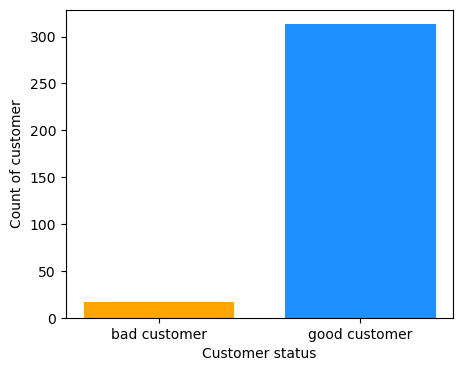

In [ ]:
bad_cust = len(df2[df2.customer_stat == 'bad'])
good_cust = len(df2[df2.customer_stat == 'good'])

label = ["bad customer", "good customer"]
value = (bad_cust, good_cust)

plt.subplots(figsize=(5, 4))
plt.bar(label, value, width=0.75, color=['orange', '#1E90FF'])
plt.ylabel("Count of customer")
plt.xlabel("Customer status")
plt.show()

In [ ]:
df2.groupby("customer_stat")["customer_id"].count()

customer_stat
bad      17
good    313
Name: customer_id, dtype: int64

#### Insight:
By far, good customer > bad customer. But in term of dataset, there is imbalance dataset that we should handle for next predictive modeling purposes.

In [ ]:
df2.tail()

,index,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,...,installment_amount,fund_transfer_ts,payment_id,payment_number_p1,due_date_p1,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,customer_stat
325,445,2021-04-02 09:59:06,2004026283775,2003023835969,Renovasi Rumah,renovasi rumah perbaikan atap rumah bocor,1982-10-12,DKI Jakarta,Menikah,1.0,...,1065000.0,2021-04-12 07:50:22,2.006022e+12,6.0,2021-10-12,0.0,2021-10-22,1065000.0,10.0,good
326,447,2021-05-06 04:04:23,2004026541054,2003023971833,Kebutuhan sehari-hari,renovasi rumah perbaikan atap rumah bocor,1994-02-05,Jawa Barat,Menikah,0.0,...,620000.0,2021-05-11 12:16:59,2.006023e+12,3.0,2021-07-30,0.0,2021-08-25,620000.0,26.0,good
327,448,2021-06-09 02:39:48,2004026770549,2003023874771,Kebutuhan sehari-hari,selamat pagi julo saya mengajukan limit julo k...,1992-04-11,Jawa Barat,Menikah,0.0,...,310000.0,2022-01-12 12:07:55,2.006050e+12,1.0,2022-02-09,0.0,2022-03-07,306000.0,26.0,good
328,449,2021-03-11 03:39:05,2004026118497,2003023752181,Biaya kesehatan,untuk biaya kesehatan orang tua dan membeli ob...,1999-10-29,Jawa Barat,Lajang,0.0,...,85000.0,2021-10-16 15:51:04,2.006030e+12,2.0,2021-12-05,0.0,2022-01-04,85000.0,30.0,good
329,450,2021-03-24 05:31:55,2004026221387,2003023660704,Kebutuhan sehari-hari,"untuk tambahan nikah, dan kebutuhan sehari har...",1997-09-22,Jawa Barat,Lajang,0.0,...,906000.0,2021-03-24 09:13:08,2.006022e+12,6.0,2021-09-30,0.0,2021-10-31,906000.0,31.0,bad


In [ ]:
df2.columns

Index(['index', 'cdate', 'application_id', 'customer_id', 'loan_purpose',
       'loan_purpose_desc', 'dob', 'address_provinsi', 'marital_status',
       'dependent', 'job_type', 'job_industry', 'loan_id', 'loan_amount',
       'loan_duration', 'installment_amount', 'fund_transfer_ts', 'payment_id',
       'payment_number_p1', 'due_date_p1', 'due_amount_p1', 'paid_date_p1',
       'paid_amount_p1', 'dpd_p1', 'customer_stat'],
      dtype='object')

In [ ]:
df2.loan_duration.unique()

array([5., 6., 3., 4., 1., 2., 9., 8., 7.])

In [ ]:
df2.dpd_p1.unique()

array([ 44.,  33.,  30.,  29.,  26.,  27.,   8.,  31.,  25.,  28.,   0.,
        24.,   2.,  16., -35.,  20.,  49.,  57., -33.,  11.,  19.,  32.,
        22.,  -4., -10.,  -2.,  21.,   7.,   1.,  17.,   6., -27.,  -7.,
        -3.,  23.,  15., -22.,  67.,   5.,  -5., -40., -28., -30., -14.,
        12.,  50.,  -1.,  14., -32.,  18.,  10.])

#### 2.3 Cumulative Default Rate

In [ ]:
#cumulative default rate
cdr = query_from_db('''WITH LoansWithDeciles AS (
  SELECT
  customer_id,
    loan_id,
    application_id,
    loan_amount,
    dpd_p1,
    NTILE(10) OVER (ORDER BY loan_amount) AS loan_decile
  FROM
    df_cust
)

SELECT
customer_id,
  loan_decile,
  COUNT(*) AS num_loans,
  SUM(CASE WHEN dpd_p1 > 0 THEN 1 ELSE 0 END) AS num_defaulted_loans,
  CAST(SUM(CASE WHEN dpd_p1 > 0 THEN 1 ELSE 0 END) AS FLOAT) / COUNT(*) AS default_rate,
  SUM(CASE WHEN dpd_p1 > 0 THEN 1 ELSE 0 END) OVER (ORDER BY loan_decile) AS cumulative_default_count,
  SUM(CAST(SUM(CASE WHEN dpd_p1 > 0 THEN 1 ELSE 0 END) AS FLOAT) / COUNT(*)) OVER (ORDER BY loan_decile) AS cumulative_default_rate,
  MIN(loan_amount) OVER (PARTITION BY loan_decile) AS min_loan_amount,
  MAX(loan_amount) OVER (PARTITION BY loan_decile) AS max_loan_amount,
  AVG(loan_amount) OVER (PARTITION BY loan_decile) AS avg_loan_amount
FROM
  LoansWithDeciles
GROUP BY
  loan_decile
ORDER BY
  loan_decile;''', engine)

cdr

,customer_id,loan_decile,num_loans,num_defaulted_loans,default_rate,cumulative_default_count,cumulative_default_rate,min_loan_amount,max_loan_amount,avg_loan_amount
0,2003024651292,1,33,31,0.939394,1,0.939394,10453.0,10453.0,10453.0
1,2003022195942,2,33,30,0.909091,2,1.848485,53684.0,53684.0,53684.0
2,2003024052721,3,33,26,0.787879,3,2.636364,264211.0,264211.0,264211.0
3,2003024035315,4,33,26,0.787879,4,3.424242,500000.0,500000.0,500000.0
4,2003024857210,5,33,28,0.848485,5,4.272727,500000.0,500000.0,500000.0
5,2003022737298,6,33,26,0.787879,5,5.060606,1000000.0,1000000.0,1000000.0
6,2003020490634,7,33,29,0.878788,6,5.939394,1500000.0,1500000.0,1500000.0
7,2003024947975,8,33,28,0.848485,7,6.787879,2000000.0,2000000.0,2000000.0
8,2003023885391,9,33,29,0.878788,8,7.666667,3500000.0,3500000.0,3500000.0
9,2003023453957,10,33,31,0.939394,9,8.606061,4500000.0,4500000.0,4500000.0


Key take away:

We use a common table expression (CTE) called `LoansWithDeciles` to calculate the decile for each loan based on the "loan amount" using the `NTILE` window function.

Within the main query, we aggregate the data for each decile and calculate the following for each decile:

* `num_loan`: Number of loans in the decile.
* `num_defaulted_loan`: Number of defaulted loans in the decile.
* `default_rate`: The default rate for the decile.
* `cumulative_default_count`: Cumulative count of defaulted loans up to the current decile.
* `cumulative_default_rate`: Cumulative default rate up to the current decile.
* `min_loan_amount`: Minimum "loan amount" in the decile.
* `max_loan_amount`: Maximum "loan amount" in the decile.
* `avg_loan_amount`: Average "loan amount" in the decile.
This query will provide the desired information organized by deciles based on "loan amount."

In [ ]:
cdr.to_sql(name='cdr', con=engine, if_exists='replace')

10

In [ ]:
target_mapper = {'bad':1, 'good':0}
def target_encode(val):
    return target_mapper[val]

df2['customer_stat'] = df2['customer_stat'].apply(target_encode)

In [ ]:
#!pip install dataprep
df2.head()

,index,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,...,installment_amount,fund_transfer_ts,payment_id,payment_number_p1,due_date_p1,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,customer_stat
0,0,2021-01-07 13:45:43,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,...,140000.0,2021-01-24 12:17:45,2.006022e+12,2.0,2021-04-02,0.0,2021-05-16,195000.0,44.0,1
1,3,2021-04-22 07:15:09,2004026435734,2003023912156,Modal usaha,renovasi rumah perbaikan atap rumah bocor,1996-01-16,Jawa Barat,Menikah,1.0,...,680000.0,2021-08-12 03:28:14,2.006023e+12,1.0,2021-09-14,0.0,2021-10-17,698000.0,33.0,1
2,5,2021-05-12 06:17:10,2004026582292,2003023805529,Kebutuhan sehari-hari,renovasi rumah perbaikan atap rumah bocor,1984-04-24,Jawa Barat,Menikah,1.0,...,82000.0,2021-05-23 13:31:06,2.006023e+12,1.0,2021-06-11,0.0,2021-07-11,78000.0,30.0,0
3,6,2021-01-09 08:56:42,2004025703643,2003021445342,Renovasi Rumah,untuk merenovasi rumah yang saya tempati,1983-03-26,Jawa Barat,Menikah,2.0,...,355000.0,2021-01-09 09:45:45,2.006022e+12,2.0,2021-03-17,0.0,2021-04-15,355000.0,29.0,0
4,8,2021-01-10 08:38:49,2004025708676,2003022313019,Biaya pendidikan,"Menunjang belajar online berupa komputer, mode...",1974-11-03,Banten,Menikah,3.0,...,300000.0,2021-04-14 09:52:32,2.006022e+12,4.0,2021-08-01,0.0,2021-08-27,300000.0,26.0,0


### Assignment 3 - Feature Engineering

Based on your findings in Assignment 2, please create features using SQL that you think could be predictive for a machine learning model.

In [ ]:
df2.columns

Index(['index', 'cdate', 'application_id', 'customer_id', 'loan_purpose',
       'loan_purpose_desc', 'dob', 'address_provinsi', 'marital_status',
       'dependent', 'job_type', 'job_industry', 'loan_id', 'loan_amount',
       'loan_duration', 'installment_amount', 'fund_transfer_ts', 'payment_id',
       'payment_number_p1', 'due_date_p1', 'due_amount_p1', 'paid_date_p1',
       'paid_amount_p1', 'dpd_p1', 'customer_stat'],
      dtype='object')

#### Demographic Information:
Include demographic features like age, marital status, dependent count, job type, and job industry as mentioned earlier.
These features provide insights into the customer's credit behavior within different credit score deciles, their consistency, and any trends or changes in their default behavior. Combine these features with the demographic information to build a comprehensive set of predictive features for a credit scoring model.

1. Age of the Customer:
* Calculate the age of the customer based on the date of birth (DOB) and the current date (cdate).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   cdate               411 non-null    datetime64[ns]
 1   application_id      451 non-null    int64         
 2   customer_id         451 non-null    int64         
 3   loan_purpose        451 non-null    object        
 4   loan_purpose_desc   451 non-null    object        
 5   dob                 411 non-null    datetime64[ns]
 6   address_provinsi    451 non-null    object        
 7   marital_status      451 non-null    object        
 8   dependent           451 non-null    float64       
 9   job_type            451 non-null    object        
 10  job_industry        451 non-null    object        
 11  loan_id             451 non-null    int64         
 12  loan_amount         451 non-null    float64       
 13  loan_duration       451 non-null    float64       

In [ ]:
query_from_db('''SELECT
  customer_id,
  cdate,
  dob,
  CAST(STRFTIME('%Y', 'now') - STRFTIME('%Y', dob) AS INTEGER) AS customer_age
FROM
  df_cust''', engine)


,customer_id,cdate,dob,customer_age
0,2003023548799,2021-01-07 13:45:43.000000,2000-01-06 00:00:00.000000,23.0
1,2003023912156,2021-04-22 07:15:09.000000,1996-01-16 00:00:00.000000,27.0
2,2003023805529,2021-05-12 06:17:10.000000,1984-04-24 00:00:00.000000,39.0
3,2003021445342,2021-01-09 08:56:42.000000,1983-03-26 00:00:00.000000,40.0
4,2003022313019,2021-01-10 08:38:49.000000,1974-11-03 00:00:00.000000,49.0
...,...,...,...,...
325,2003023835969,2021-04-02 09:59:06.000000,1982-10-12 00:00:00.000000,41.0
326,2003023971833,2021-05-06 04:04:23.000000,1994-02-05 00:00:00.000000,29.0
327,2003023874771,2021-06-09 02:39:48.000000,1992-04-11 00:00:00.000000,31.0
328,2003023752181,2021-03-11 03:39:05.000000,1999-10-29 00:00:00.000000,24.0


In [ ]:
df_age = query_from_db('''SELECT
  customer_id,
  cdate,
  dob,
  CAST(STRFTIME('%Y', 'now') - STRFTIME('%Y', dob) AS INTEGER) AS customer_age
FROM
  df_cust''', engine)

df_age.customer_age.unique()

array([23., 27., 39., 40., 49., nan, 43., 24., 28., 34., 38., 47., 32.,
       33., 29., 35., 37., 41., 61., 30., 25., 26., 42., 31., 51., 36.,
       44., 45., 48., 53., 50., 55., 52., 46., 54., 56.])

In [ ]:
#fillna in customer age with median (because age med = age mean) since there are na in dob
df_age.customer_age = df_age.customer_age.fillna(df_age.customer_age.median())

In [ ]:
df_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   330 non-null    int64  
 1   cdate         305 non-null    object 
 2   dob           299 non-null    object 
 3   customer_age  330 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 10.4+ KB


2. Outstanding Loan Balance:
* Calculate the outstanding balance for each loan.

In [ ]:
df_outbal = query_from_db('''SELECT
  customer_id,
  loan_id,
  loan_amount - SUM(paid_amount_p1) OVER (PARTITION BY customer_id, loan_id ORDER BY payment_number_p1) AS outstanding_balance
FROM
  df_cust''', engine)

df_outbal

,customer_id,loan_id,outstanding_balance
0,2003020231588,2005020931793,750000.0
1,2003020234027,2005020635406,3014000.0
2,2003020290264,2005021398996,891000.0
3,2003020300323,2005020889627,-1107.0
4,2003020308160,2005020872263,-4599.0
...,...,...,...
325,2003025058083,2005021470406,2499000.0
326,2003025092572,2005021902049,-1375.0
327,2003025120873,2005021541187,1481000.0
328,2003025128338,2005021759979,-3661.0


**5. Merge dataset**

In [ ]:

df3 = pd.merge(pd.merge(df2,df_age, on= 'customer_id', how='inner'),
                                 df_outbal, on= 'customer_id', how='inner')

df3.head()

,index,cdate_x,application_id,customer_id,loan_purpose,loan_purpose_desc,dob_x,address_provinsi,marital_status,dependent,...,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,customer_stat,cdate_y,dob_y,customer_age,loan_id_y,outstanding_balance
0,0,2021-01-07 13:45:43,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,...,0.0,2021-05-16,195000.0,44.0,1,2021-01-07 13:45:43.000000,2000-01-06 00:00:00.000000,23.0,2005020645489,305000.0
1,3,2021-04-22 07:15:09,2004026435734,2003023912156,Modal usaha,renovasi rumah perbaikan atap rumah bocor,1996-01-16,Jawa Barat,Menikah,1.0,...,0.0,2021-10-17,698000.0,33.0,1,2021-04-22 07:15:09.000000,1996-01-16 00:00:00.000000,27.0,2005020973075,2302000.0
2,5,2021-05-12 06:17:10,2004026582292,2003023805529,Kebutuhan sehari-hari,renovasi rumah perbaikan atap rumah bocor,1984-04-24,Jawa Barat,Menikah,1.0,...,0.0,2021-07-11,78000.0,30.0,0,2021-05-12 06:17:10.000000,1984-04-24 00:00:00.000000,39.0,2005020780199,132895.0
3,6,2021-01-09 08:56:42,2004025703643,2003021445342,Renovasi Rumah,untuk merenovasi rumah yang saya tempati,1983-03-26,Jawa Barat,Menikah,2.0,...,0.0,2021-04-15,355000.0,29.0,0,2021-01-09 08:56:42.000000,1983-03-26 00:00:00.000000,40.0,2005020633867,1145000.0
4,8,2021-01-10 08:38:49,2004025708676,2003022313019,Biaya pendidikan,"Menunjang belajar online berupa komputer, mode...",1974-11-03,Banten,Menikah,3.0,...,0.0,2021-08-27,300000.0,26.0,0,2021-01-10 08:38:49.000000,1974-11-03 00:00:00.000000,49.0,2005020722554,700000.0


In [ ]:
df3.columns

Index(['index', 'cdate_x', 'application_id', 'customer_id', 'loan_purpose',
       'loan_purpose_desc', 'dob_x', 'address_provinsi', 'marital_status',
       'dependent', 'job_type', 'job_industry', 'loan_id_x', 'loan_amount',
       'loan_duration', 'installment_amount', 'fund_transfer_ts', 'payment_id',
       'payment_number_p1', 'due_date_p1', 'due_amount_p1', 'paid_date_p1',
       'paid_amount_p1', 'dpd_p1', 'customer_stat', 'cdate_y', 'dob_y',
       'customer_age', 'loan_id_y', 'outstanding_balance'],
      dtype='object')

In [ ]:
#drop duplicate columns
df4 = df3.drop(['index','cdate_y', 'dob_y', 'loan_id_y'],
        axis=1, inplace=False)

In [ ]:
df4.columns

Index(['cdate_x', 'application_id', 'customer_id', 'loan_purpose',
       'loan_purpose_desc', 'dob_x', 'address_provinsi', 'marital_status',
       'dependent', 'job_type', 'job_industry', 'loan_id_x', 'loan_amount',
       'loan_duration', 'installment_amount', 'fund_transfer_ts', 'payment_id',
       'payment_number_p1', 'due_date_p1', 'due_amount_p1', 'paid_date_p1',
       'paid_amount_p1', 'dpd_p1', 'customer_stat', 'customer_age',
       'outstanding_balance'],
      dtype='object')

In [ ]:
#rename column name
df4.columns.values[0]= 'cdate'
df4.columns.values[5]= 'dob'
df4.columns.values[11]= 'loan_id'


In [ ]:
df4.columns

Index(['cdate', 'application_id', 'customer_id', 'loan_purpose',
       'loan_purpose_desc', 'dob', 'address_provinsi', 'marital_status',
       'dependent', 'job_type', 'job_industry', 'loan_id', 'loan_amount',
       'loan_duration', 'installment_amount', 'fund_transfer_ts', 'payment_id',
       'payment_number_p1', 'due_date_p1', 'due_amount_p1', 'paid_date_p1',
       'paid_amount_p1', 'dpd_p1', 'customer_stat', 'customer_age',
       'outstanding_balance'],
      dtype='object')

In [ ]:
df4.head()

,cdate,application_id,customer_id,loan_purpose,loan_purpose_desc,dob,address_provinsi,marital_status,dependent,job_type,...,payment_id,payment_number_p1,due_date_p1,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,customer_stat,customer_age,outstanding_balance
0,2021-01-07 13:45:43,2004025695250,2003023548799,Modal usaha,untuk usaha membuat makanan / camilan / kue,2000-01-06,Banten,Lajang,1.0,Pegawai swasta,...,2.006022e+12,2.0,2021-04-02,0.0,2021-05-16,195000.0,44.0,1,23.0,305000.0
1,2021-04-22 07:15:09,2004026435734,2003023912156,Modal usaha,renovasi rumah perbaikan atap rumah bocor,1996-01-16,Jawa Barat,Menikah,1.0,Pegawai swasta,...,2.006023e+12,1.0,2021-09-14,0.0,2021-10-17,698000.0,33.0,1,27.0,2302000.0
2,2021-05-12 06:17:10,2004026582292,2003023805529,Kebutuhan sehari-hari,renovasi rumah perbaikan atap rumah bocor,1984-04-24,Jawa Barat,Menikah,1.0,Pegawai swasta,...,2.006023e+12,1.0,2021-06-11,0.0,2021-07-11,78000.0,30.0,0,39.0,132895.0
3,2021-01-09 08:56:42,2004025703643,2003021445342,Renovasi Rumah,untuk merenovasi rumah yang saya tempati,1983-03-26,Jawa Barat,Menikah,2.0,Pegawai swasta,...,2.006022e+12,2.0,2021-03-17,0.0,2021-04-15,355000.0,29.0,0,40.0,1145000.0
4,2021-01-10 08:38:49,2004025708676,2003022313019,Biaya pendidikan,"Menunjang belajar online berupa komputer, mode...",1974-11-03,Banten,Menikah,3.0,Pegawai swasta,...,2.006022e+12,4.0,2021-08-01,0.0,2021-08-27,300000.0,26.0,0,49.0,700000.0


### Assignment 4 - Data Visualization
Using the features you engineered in Assignment 3, could you visualize the data to show a business user that your features are useful?

In [ ]:
#pip install pandas==1.4.16

In [ ]:
#pip install dataprep --upgrade

In [ ]:
#Auto EDA
#from dataprep.eda import create_report
#from dataprep.eda import plot_correlation

In [ ]:
#report = create_report(df4)
#report.show()

/var/folders/z2/fsr3hf6j6cn61s87b2hj3xxr0000gn/T/ipykernel_962/1779945487.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(x="outstanding_balance", y="dpd_p1",


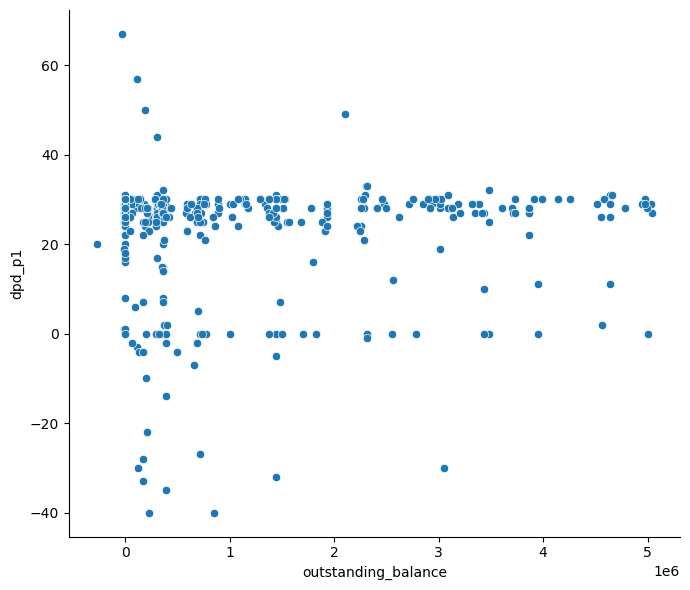

In [ ]:
import seaborn as sns
sns.relplot(x="outstanding_balance", y="dpd_p1",
            sizes=(20, 600), alpha=1, palette="magma",
            height=6, data=df4, aspect=14/12)

/var/folders/z2/fsr3hf6j6cn61s87b2hj3xxr0000gn/T/ipykernel_962/246019883.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df4['loan_amount'])


<AxesSubplot:xlabel='loan_amount', ylabel='Density'>

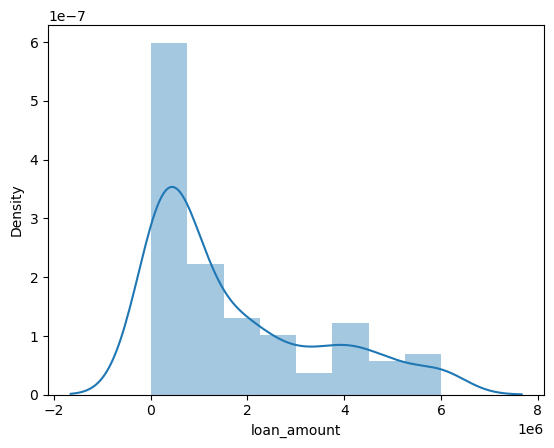

In [ ]:
sns.distplot(df4['loan_amount'])

In [ ]:
#conda install -c conda-forge seaborn=0.12.2

#### Insight:
Most of the customers have applied a loan for a amount between Rp 1 mio and Rp 2 mio and a higher number of customers have applied for a loan of Rp 1 mio.

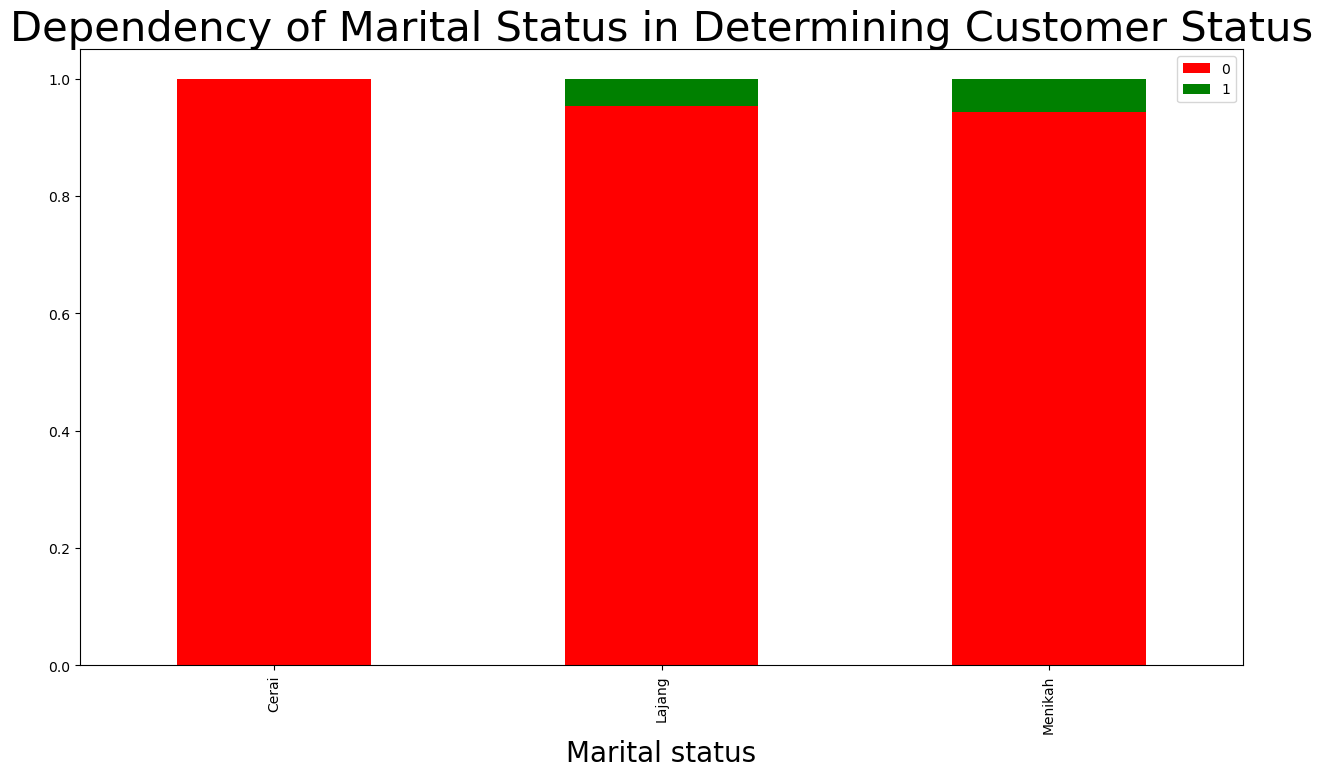

In [ ]:
data = pd.crosstab(df4['marital_status'],df4['customer_stat'])
data.div(data.sum(1).astype('float'), axis = 0).plot(kind = 'bar', stacked = True, figsize = (15, 8), color = ['Red', 'Green','Blue'])
plt.title('Dependency of Marital Status in Determining Customer Status', fontsize = 30)
plt.xlabel('Marital status', fontsize = 20)
plt.legend()
plt.show()

#### Insight:
Here, we can observe that single and married customers have more likelihood to default on loans.

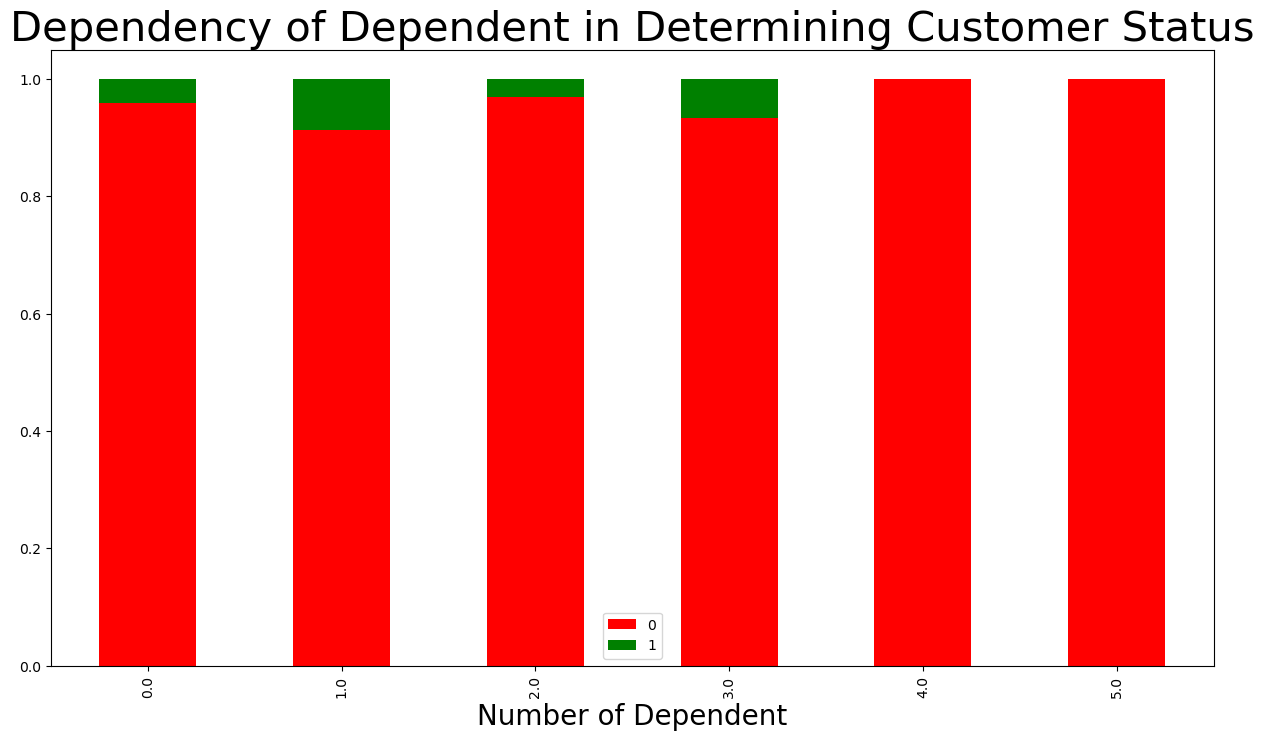

In [ ]:
data = pd.crosstab(df4['dependent'],df4['customer_stat'])
data.div(data.sum(1).astype('float'), axis = 0).plot(kind = 'bar', stacked = True, figsize = (15, 8), color = ['Red', 'Green','Blue'])
plt.title('Dependency of Dependent in Determining Customer Status', fontsize = 30)
plt.xlabel('Number of Dependent', fontsize = 20)
plt.legend()
plt.show()

#### Insight:
We can see that customers who have 1 & 3 dependents are tend to be worse in terms of loan repayment. Meaning that having a few dependant is not guarante of being good customers.

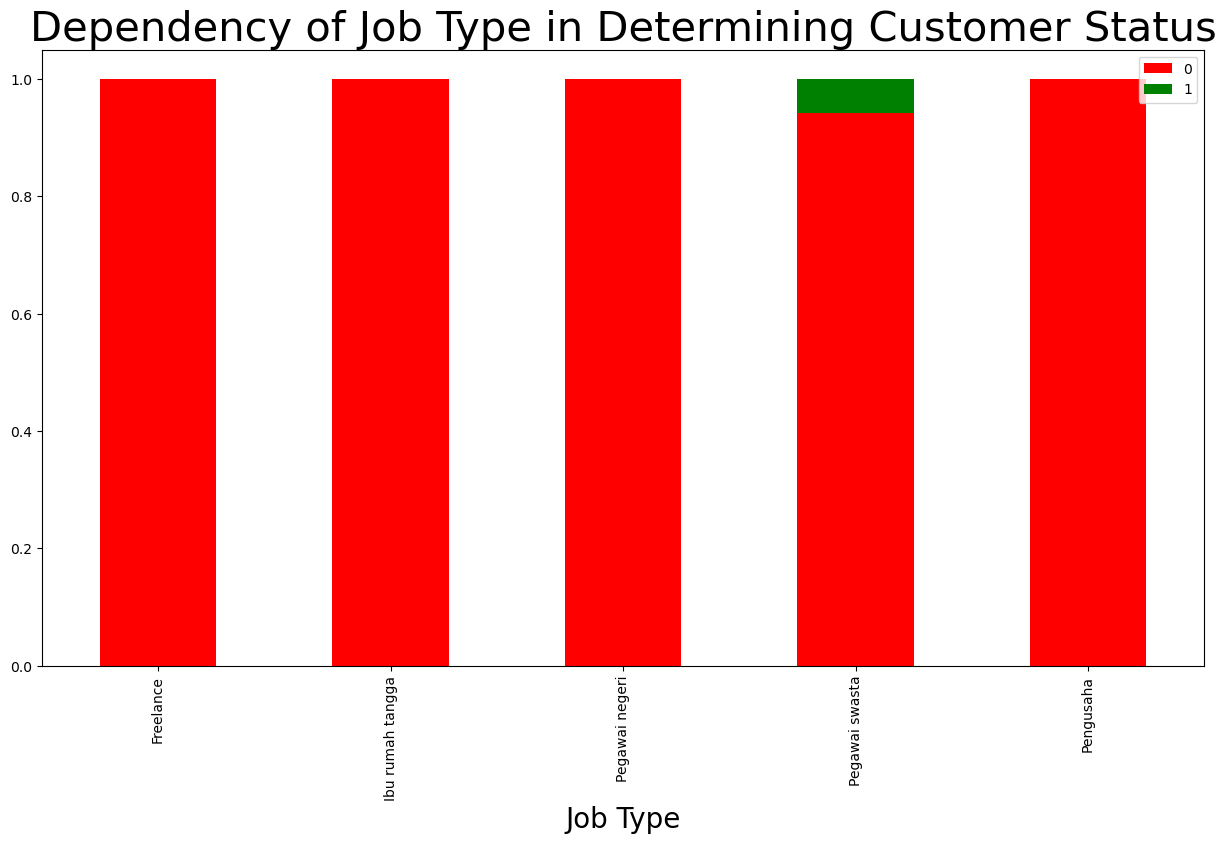

In [ ]:
data = pd.crosstab(df4['job_type'],df4['customer_stat'])
data.div(data.sum(1).astype('float'), axis = 0).plot(kind = 'bar', stacked = True, figsize = (15, 8), color = ['Red', 'Green','Blue'])
plt.title('Dependency of Job Type in Determining Customer Status', fontsize = 30)
plt.xlabel('Job Type', fontsize = 20)
plt.legend()
plt.show()

#### Insight:
Pegawai swasta is the most majority of default on loans.

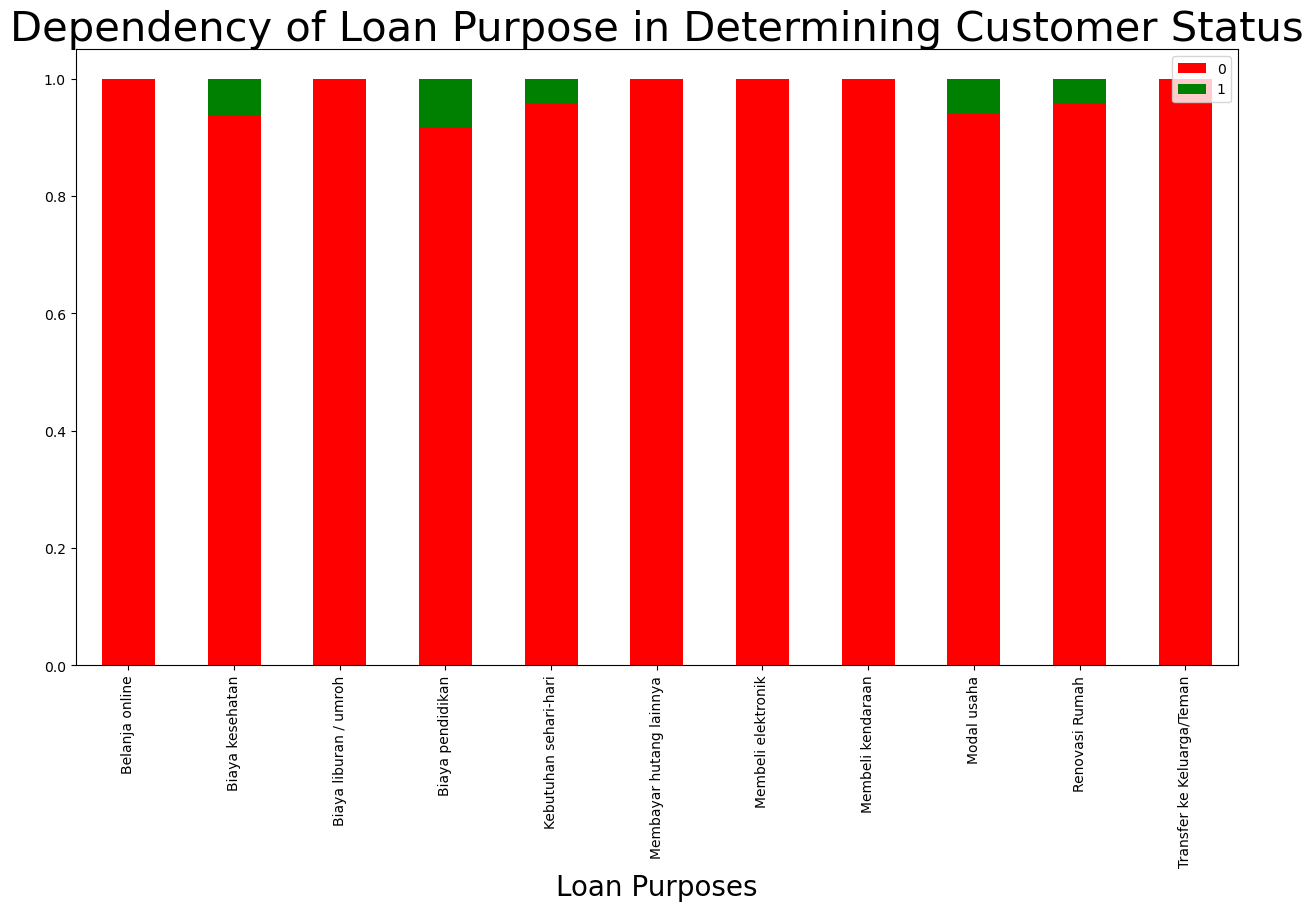

In [ ]:
data = pd.crosstab(df4['loan_purpose'],df4['customer_stat'])
data.div(data.sum(1).astype('float'), axis = 0).plot(kind = 'bar', stacked = True, figsize = (15, 8), color = ['Red', 'Green','Blue'])
plt.title('Dependency of Loan Purpose in Determining Customer Status', fontsize = 30)
plt.xlabel('Loan Purposes', fontsize = 20)
plt.legend()
plt.show()

#### Insight:
Most of the customers have opted for laon for biaya pendidikan and followed by biaya kesehatan and modal usaha are tend to be worse in loan repayment.

In [ ]:
#Import packages for data analysis
import os
import tarfile
from six.moves import urllib

# Import and suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# function for plotting distribution of data
from scipy.stats import ttest_ind
from matplotlib.pyplot import figure, subplot

# separate dataset cust stat bad/good
bad_cust = df4.loc[df4['customer_stat'] == 1]
good_cust = df4.loc[df4['customer_stat'] == 0]

def plot_samples(attribute):

    # plot options
    label_font = 18

    # select independent samples
    sample_B = bad_cust[attribute]
    sample_G = good_cust[attribute]


    # Plot
    data = [sample_B,sample_G]

    figure(figsize=(17,5))
    plt.suptitle('Distribution of '+ attribute, fontsize=label_font+2)
    p1 = subplot(1,2,1)
    # Box plot
    box = plt.boxplot(data,patch_artist=True)
    colors = ['red', '#1EEB65']

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    plt.ylabel(attribute,fontsize=label_font)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=14)
    plt.xlabel("customer status",fontsize=label_font)
    p1.set_xticklabels(['BAD','GOOD'])


    # Distribution
    p2 = subplot(1,2,2)
    sns.kdeplot(sample_B,color ='red', shade = "True", label="Bad Customer")
    sns.kdeplot(sample_G,color ='g', shade = "True", label="Good Customer")
    plt.xlabel(attribute,fontsize=label_font)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12)

    return

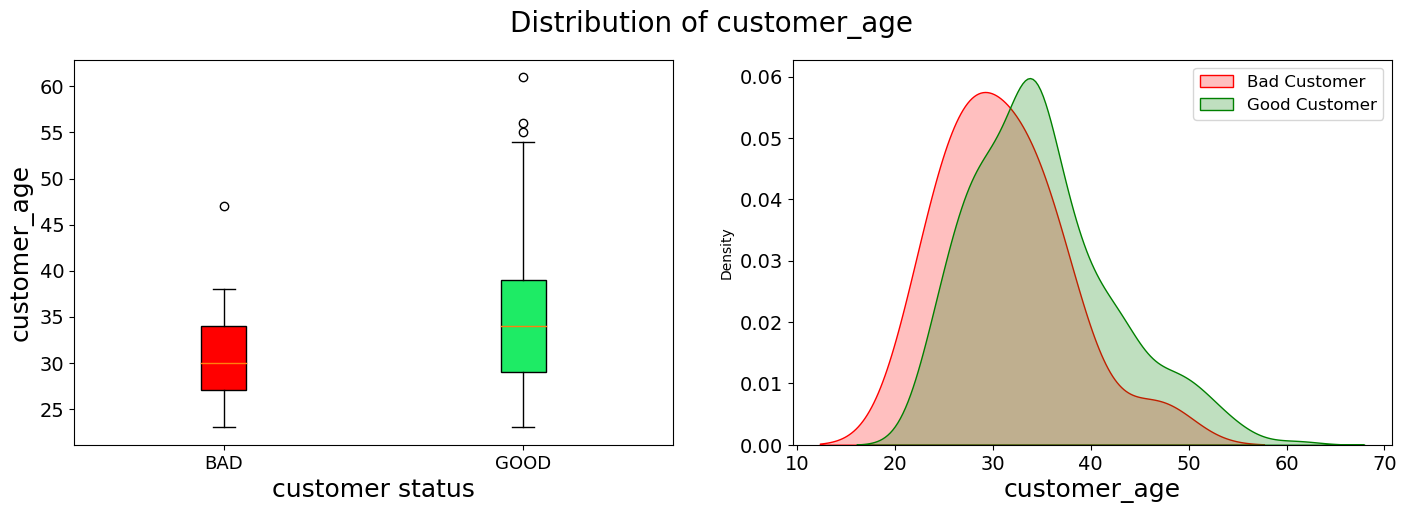

In [ ]:
plot_samples('customer_age')

#### Insight:

* From the Age Comparision boxplot, majority of customers who tend to default on loan are customer under 30  and under 40 yo.
* Most of the customers tend to default on loan are customer under 30 yp.

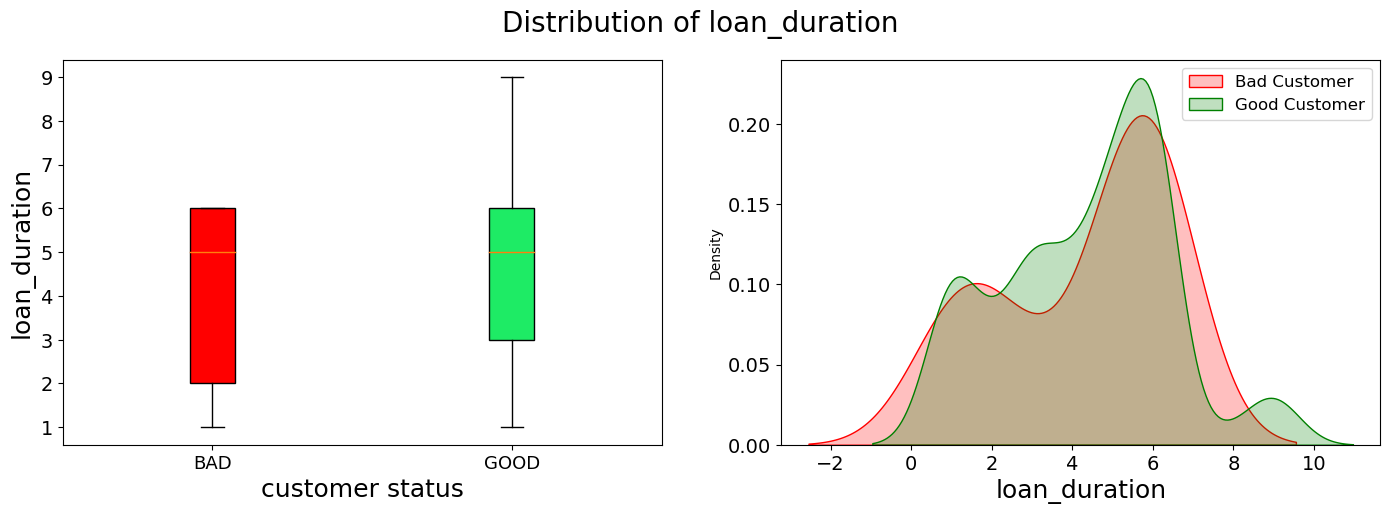

In [ ]:
plot_samples('loan_duration')

#### Insight:
Long loan duaration is prone in causing customers to default.

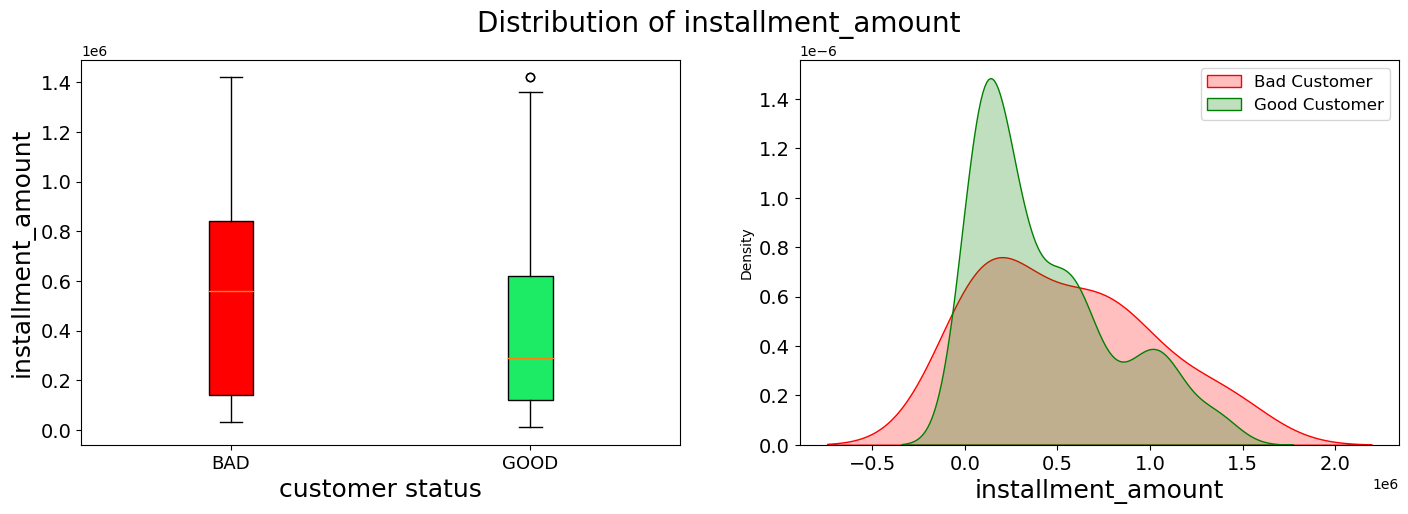

In [ ]:
plot_samples('installment_amount')

##### Insight:
Majority of the customers tend to be worse in terms of repayment behavior are customers who took loan installment around 500K

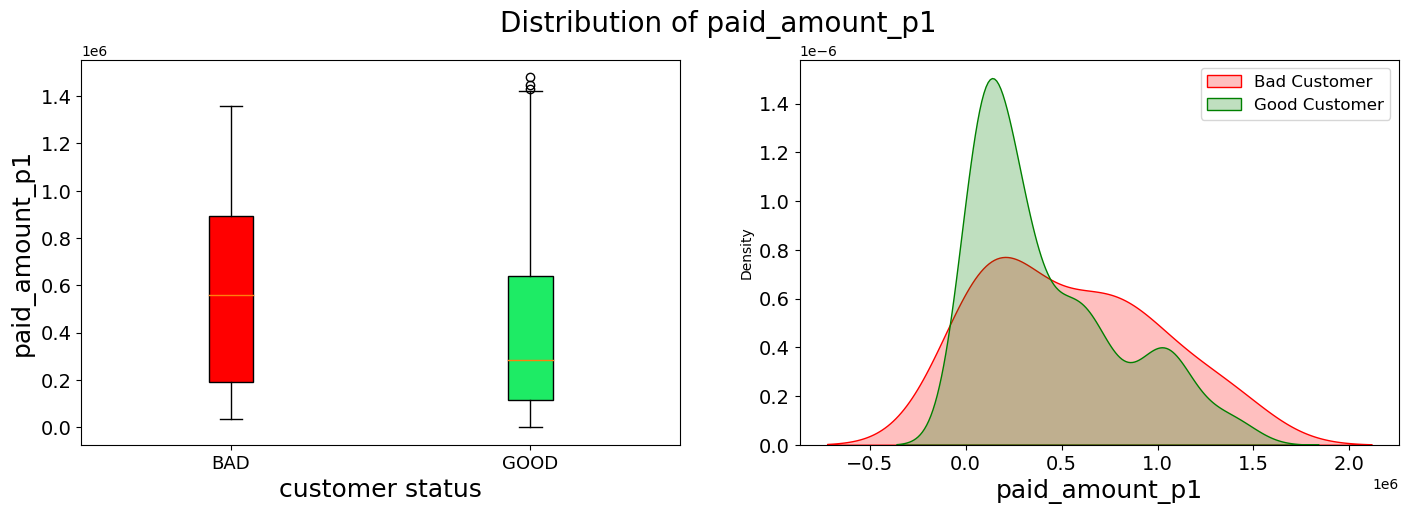

In [ ]:
plot_samples('paid_amount_p1')

#### Insight:
Majority of the customers tend to be worse in terms of repayment behavior are customers who paid loan 500K.

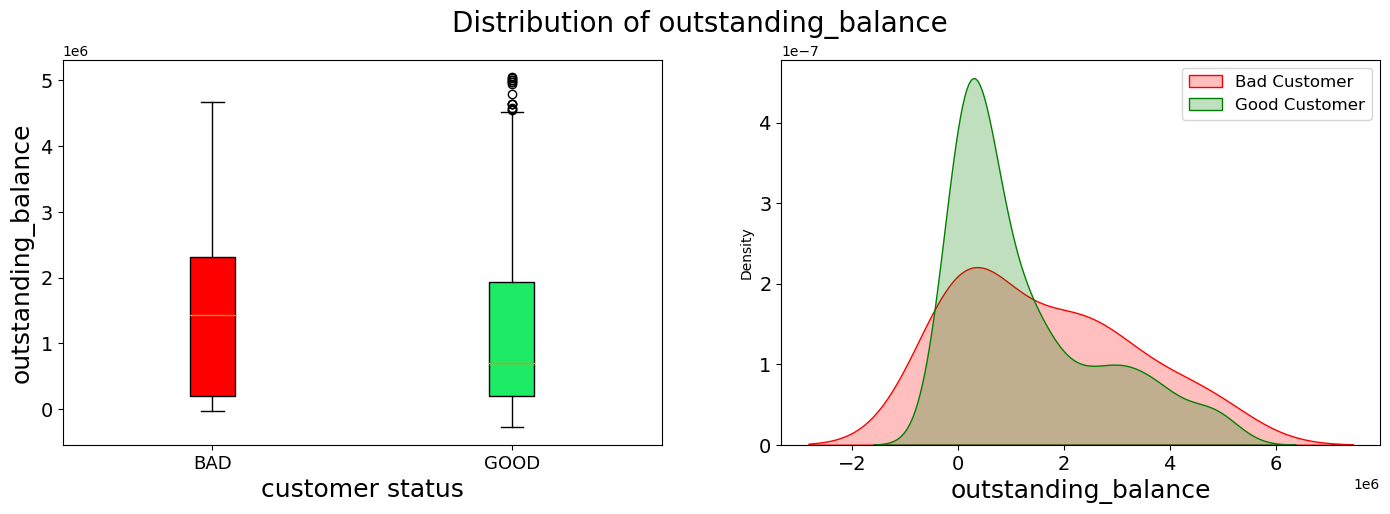

In [ ]:
plot_samples('outstanding_balance')

#### Insight:
Majority of the customers tend to be worse in terms of repayment behavior are customers who have outstanding balance  1-2 mio.

In [ ]:
# partition numerical dan categorical
numerical_col = df4.select_dtypes(exclude=np.object_)
categorical_col = df4.select_dtypes(exclude=np.number)

In [ ]:
#sns.pairplot(numerical_col,hue='customer_stat')

**Key takeaways:**
Based on findings from data visualization, we identify trends and patterns in the data and can gain insights of the characteristics and customer behaviors that distinguish good customers from bad ones. Overall important points that are considerable:
* By demographic, majority of the customers opted for laon for modal usaha and renovasi rumah. Where most customers are single without dependent and aged under 30 come from Jawa Barat.
* Pegawai swasta are more likely to default on loans.
* Customers with more dependents tend to be worse in terms of repayment behavior.
* Married customers have a higher likelihood of being bad customers than single or divorce customers.
* Younger customers have more likelihood of being default on loan. Specifically, customers between 25 - 30 yo are tend to be bad customers.

### Assignment 5 - Modeling

1. Please build model(s) using the label and features that you have developed.
2. Which metrics do you use? and why?
3. Explain why your model can be considered as good enough.
4. How can the business use the model?
5. Could you provide which customers/loan we should avoid? Why?
6. If the business would like to achieve 2% cumulative default rate, which loans should we accept?
7. What are the characteristics of a defaulter, and how important are they?

In [ ]:
categorical_col.columns

Index(['cdate', 'loan_purpose', 'loan_purpose_desc', 'dob', 'address_provinsi',
       'marital_status', 'job_type', 'job_industry', 'fund_transfer_ts',
       'due_date_p1', 'paid_date_p1'],
      dtype='object')

In [ ]:
#Encode categorical features
loan_purpose = pd.get_dummies(df4['loan_purpose'], prefix='loan_purpose')
address_provinsi = pd.get_dummies(df4['address_provinsi'], prefix='address_provinsi')
marital_status = pd.get_dummies(df4['marital_status'], prefix='marital_status')
job_type = pd.get_dummies(df4['job_type'], prefix='job_type')
job_industry = pd.get_dummies(df4['job_industry'], prefix='job_industry')

df4.drop(columns=['loan_purpose','address_provinsi', 'marital_status','job_type', 'job_industry'] , inplace=True)
frames = [loan_purpose, address_provinsi,marital_status, job_type, job_industry]
df5 = pd.concat(frames, axis = 1)

In [ ]:
df5.shape

(330, 60)

In [ ]:
df5.columns

Index(['loan_purpose_Belanja online', 'loan_purpose_Biaya kesehatan',
       'loan_purpose_Biaya liburan / umroh', 'loan_purpose_Biaya pendidikan',
       'loan_purpose_Kebutuhan sehari-hari',
       'loan_purpose_Membayar hutang lainnya',
       'loan_purpose_Membeli elektronik', 'loan_purpose_Membeli kendaraan',
       'loan_purpose_Modal usaha', 'loan_purpose_Renovasi Rumah',
       'loan_purpose_Transfer ke Keluarga/Teman', 'address_provinsi_Bali',
       'address_provinsi_Banten', 'address_provinsi_Bengkulu',
       'address_provinsi_DI Yogyakarta', 'address_provinsi_DKI Jakarta',
       'address_provinsi_Jawa Barat', 'address_provinsi_Jawa Tengah',
       'address_provinsi_Jawa Timur', 'address_provinsi_Kalimantan Barat',
       'address_provinsi_Kalimantan Selatan',
       'address_provinsi_Kalimantan Tengah',
       'address_provinsi_Kalimantan Timur',
       'address_provinsi_Kalimantan Utara', 'address_provinsi_Kepulauan Riau',
       'address_provinsi_Lampung', 'address_prov

In [ ]:
df5.head()

,loan_purpose_Belanja online,loan_purpose_Biaya kesehatan,loan_purpose_Biaya liburan / umroh,loan_purpose_Biaya pendidikan,loan_purpose_Kebutuhan sehari-hari,loan_purpose_Membayar hutang lainnya,loan_purpose_Membeli elektronik,loan_purpose_Membeli kendaraan,loan_purpose_Modal usaha,loan_purpose_Renovasi Rumah,...,job_industry_Pabrik / Gudang,job_industry_Pendidikan,job_industry_Perawatan Tubuh,job_industry_Perbankan,job_industry_Perhotelan,job_industry_Sales / Marketing,job_industry_Service,job_industry_Staf Rumah Tangga,job_industry_Tehnik / Computer,job_industry_Transportasi
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [ ]:
#convert bool to int
df5 = df5.replace({True: 1, False:0}).astype(int)

In [ ]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 60 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   loan_purpose_Belanja online                      330 non-null    int64
 1   loan_purpose_Biaya kesehatan                     330 non-null    int64
 2   loan_purpose_Biaya liburan / umroh               330 non-null    int64
 3   loan_purpose_Biaya pendidikan                    330 non-null    int64
 4   loan_purpose_Kebutuhan sehari-hari               330 non-null    int64
 5   loan_purpose_Membayar hutang lainnya             330 non-null    int64
 6   loan_purpose_Membeli elektronik                  330 non-null    int64
 7   loan_purpose_Membeli kendaraan                   330 non-null    int64
 8   loan_purpose_Modal usaha                         330 non-null    int64
 9   loan_purpose_Renovasi Rumah                      330 n

<AxesSubplot:xlabel='customer_stat', ylabel='count'>

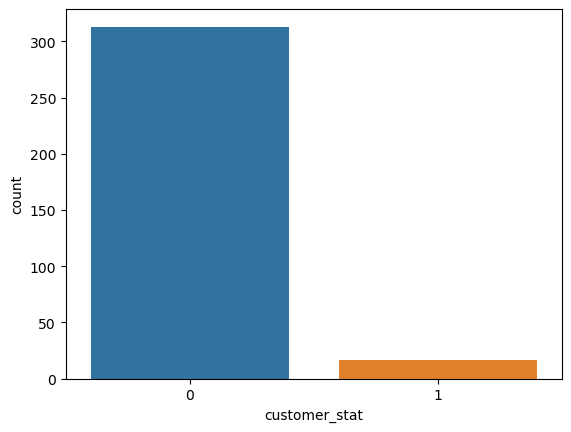

In [ ]:
#check proporsi target variable
sns.countplot(data=df4,x='customer_stat')

In [ ]:
df_final = pd.concat([df4,df5], axis=1)

In [ ]:
df_final.head()

,cdate,application_id,customer_id,loan_purpose_desc,dob,dependent,loan_id,loan_amount,loan_duration,installment_amount,...,job_industry_Pabrik / Gudang,job_industry_Pendidikan,job_industry_Perawatan Tubuh,job_industry_Perbankan,job_industry_Perhotelan,job_industry_Sales / Marketing,job_industry_Service,job_industry_Staf Rumah Tangga,job_industry_Tehnik / Computer,job_industry_Transportasi
0,2021-01-07 13:45:43,2004025695250,2003023548799,untuk usaha membuat makanan / camilan / kue,2000-01-06,1.0,2005020645489,500000.0,5.0,140000.0,...,0,0,0,0,0,0,0,0,0,0
1,2021-04-22 07:15:09,2004026435734,2003023912156,renovasi rumah perbaikan atap rumah bocor,1996-01-16,1.0,2005020973075,3000000.0,6.0,680000.0,...,1,0,0,0,0,0,0,0,0,0
2,2021-05-12 06:17:10,2004026582292,2003023805529,renovasi rumah perbaikan atap rumah bocor,1984-04-24,1.0,2005020780199,210895.0,3.0,82000.0,...,0,0,0,0,0,0,1,0,0,0
3,2021-01-09 08:56:42,2004025703643,2003021445342,untuk merenovasi rumah yang saya tempati,1983-03-26,2.0,2005020633867,1500000.0,6.0,355000.0,...,0,0,0,0,0,0,0,0,0,0
4,2021-01-10 08:38:49,2004025708676,2003022313019,"Menunjang belajar online berupa komputer, mode...",1974-11-03,3.0,2005020722554,1000000.0,4.0,300000.0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
df4.head()

,cdate,application_id,customer_id,loan_purpose_desc,dob,dependent,loan_id,loan_amount,loan_duration,installment_amount,...,payment_id,payment_number_p1,due_date_p1,due_amount_p1,paid_date_p1,paid_amount_p1,dpd_p1,customer_stat,customer_age,outstanding_balance
0,2021-01-07 13:45:43,2004025695250,2003023548799,untuk usaha membuat makanan / camilan / kue,2000-01-06,1.0,2005020645489,500000.0,5.0,140000.0,...,2.006022e+12,2.0,2021-04-02,0.0,2021-05-16,195000.0,44.0,1,23.0,305000.0
1,2021-04-22 07:15:09,2004026435734,2003023912156,renovasi rumah perbaikan atap rumah bocor,1996-01-16,1.0,2005020973075,3000000.0,6.0,680000.0,...,2.006023e+12,1.0,2021-09-14,0.0,2021-10-17,698000.0,33.0,1,27.0,2302000.0
2,2021-05-12 06:17:10,2004026582292,2003023805529,renovasi rumah perbaikan atap rumah bocor,1984-04-24,1.0,2005020780199,210895.0,3.0,82000.0,...,2.006023e+12,1.0,2021-06-11,0.0,2021-07-11,78000.0,30.0,0,39.0,132895.0
3,2021-01-09 08:56:42,2004025703643,2003021445342,untuk merenovasi rumah yang saya tempati,1983-03-26,2.0,2005020633867,1500000.0,6.0,355000.0,...,2.006022e+12,2.0,2021-03-17,0.0,2021-04-15,355000.0,29.0,0,40.0,1145000.0
4,2021-01-10 08:38:49,2004025708676,2003022313019,"Menunjang belajar online berupa komputer, mode...",1974-11-03,3.0,2005020722554,1000000.0,4.0,300000.0,...,2.006022e+12,4.0,2021-08-01,0.0,2021-08-27,300000.0,26.0,0,49.0,700000.0


# Data Modeling

In [ ]:
df_final.columns

Index(['cdate', 'application_id', 'customer_id', 'loan_purpose_desc', 'dob',
       'dependent', 'loan_id', 'loan_amount', 'loan_duration',
       'installment_amount', 'fund_transfer_ts', 'payment_id',
       'payment_number_p1', 'due_date_p1', 'due_amount_p1', 'paid_date_p1',
       'paid_amount_p1', 'dpd_p1', 'customer_stat', 'customer_age',
       'outstanding_balance', 'loan_purpose_Belanja online',
       'loan_purpose_Biaya kesehatan', 'loan_purpose_Biaya liburan / umroh',
       'loan_purpose_Biaya pendidikan', 'loan_purpose_Kebutuhan sehari-hari',
       'loan_purpose_Membayar hutang lainnya',
       'loan_purpose_Membeli elektronik', 'loan_purpose_Membeli kendaraan',
       'loan_purpose_Modal usaha', 'loan_purpose_Renovasi Rumah',
       'loan_purpose_Transfer ke Keluarga/Teman', 'address_provinsi_Bali',
       'address_provinsi_Banten', 'address_provinsi_Bengkulu',
       'address_provinsi_DI Yogyakarta', 'address_provinsi_DKI Jakarta',
       'address_provinsi_Jawa Barat',

In [ ]:
# divide into features and labels and drop unnecessary features

X = df_final.drop(['cdate', 'application_id', 'customer_id', 'loan_purpose_desc', 'dob',
                   'loan_id','fund_transfer_ts', 'payment_id','due_date_p1','paid_date_p1', 'customer_stat'],
                  axis=1)

In [ ]:
#feat_names = ['dpd_p1', 'loan_purpose_Modal usaha', 'job_industry_Admin / Finance / HR', 'customer_age', 'paid_amount_p1']
#X = df_final[feat_names]

In [ ]:
X.shape

(330, 70)

In [ ]:
X.head()

,dependent,loan_amount,loan_duration,installment_amount,payment_number_p1,due_amount_p1,paid_amount_p1,dpd_p1,customer_age,outstanding_balance,...,job_industry_Pabrik / Gudang,job_industry_Pendidikan,job_industry_Perawatan Tubuh,job_industry_Perbankan,job_industry_Perhotelan,job_industry_Sales / Marketing,job_industry_Service,job_industry_Staf Rumah Tangga,job_industry_Tehnik / Computer,job_industry_Transportasi
0,1.0,500000.0,5.0,140000.0,2.0,0.0,195000.0,44.0,23.0,305000.0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,3000000.0,6.0,680000.0,1.0,0.0,698000.0,33.0,27.0,2302000.0,...,1,0,0,0,0,0,0,0,0,0
2,1.0,210895.0,3.0,82000.0,1.0,0.0,78000.0,30.0,39.0,132895.0,...,0,0,0,0,0,0,1,0,0,0
3,2.0,1500000.0,6.0,355000.0,2.0,0.0,355000.0,29.0,40.0,1145000.0,...,0,0,0,0,0,0,0,0,0,0
4,3.0,1000000.0,4.0,300000.0,4.0,0.0,300000.0,26.0,49.0,700000.0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
y = df_final['customer_stat']

In [ ]:
y.shape

(330,)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 70 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   dependent                                        330 non-null    float64
 1   loan_amount                                      330 non-null    float64
 2   loan_duration                                    330 non-null    float64
 3   installment_amount                               330 non-null    float64
 4   payment_number_p1                                330 non-null    float64
 5   due_amount_p1                                    330 non-null    float64
 6   paid_amount_p1                                   330 non-null    float64
 7   dpd_p1                                           330 non-null    float64
 8   customer_age                                     330 non-null    float64
 9   outstanding_balance             

In [ ]:
# do train test split for features and labels

from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
# checking training sample numbers for Label ( cust status)
from collections import Counter
print(Counter(y_train))

Counter({0: 218, 1: 13})


In [ ]:

# perform Standard Scaling and SMOTE to handle imbalance between data

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


from imblearn.over_sampling import SMOTE
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train,y_train)

In [ ]:
# checking training sample numbers for Label ( customer stat) after SMOTE ( they are equal )

from collections import Counter
print(Counter(y_train))

Counter({0: 218, 1: 218})


## 7.1. Modeling

### 7.1.1.0 Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

rfc_fimp = pd.Series(rfc.feature_importances_, index = X.columns)
rfc_fimp.sort_values(ascending=False)

dpd_p1                               0.381098
job_industry_Admin / Finance / HR    0.105143
loan_purpose_Modal usaha             0.077801
customer_age                         0.071564
dependent                            0.036436
                                       ...   
address_provinsi_Kalimantan Utara    0.000000
address_provinsi_Kepulauan Riau      0.000000
address_provinsi_Sumatera Barat      0.000000
address_provinsi_Papua               0.000000
address_provinsi_Lampung             0.000000
Length: 70, dtype: float64

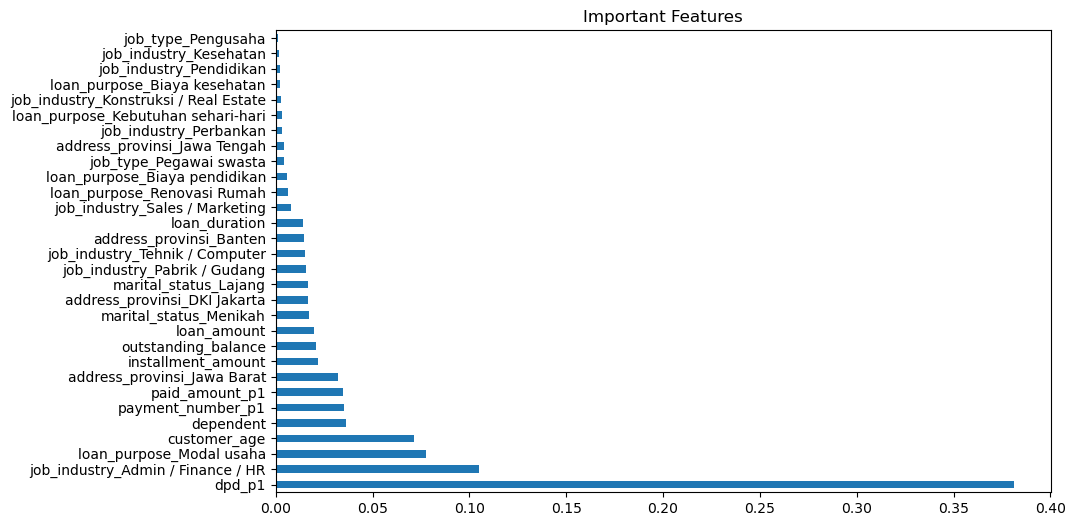

In [ ]:
plt.figure(figsize=(10,6))
rfc_fimp.nlargest(30).sort_values(ascending=False).plot(kind='barh')
round(rfc_fimp,4)*100
plt.title('Important Features',size=12)
plt.show()



RandomForest model basically calculates the importance of a feature based on Gini Importance score.

In the graph above, we can see that the most important (top 5 features) are:
1. `dpd_p1`
2. `customer_age`
3. `outstanding-balance`
4. `paid_amount_p1`
5. `installment_amount`

In [ ]:
#to fix installation lightgbm on Mac since had prior errors
#conda install -c conda-forge lightgbm

In [ ]:
#pip install --upgrade pandas "dask[complete]"

In [ ]:
#Only selected features that are filled to the model
feature_names = ['dpd_p1', 'customer_age', 'outstanding_balance','paid_amount_p1',  'installment_amount' ]
X = df_final[feature_names]


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import accuracy_score

#Split data for later
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=97)

In [ ]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

### 7.1.1 Compare All Base Models

In [ ]:
# Step 1: create a list containing all estimators with their default parameters
random_state = 97
est_list = [LGBMClassifier(random_state=random_state),XGBClassifier(random_state=random_state),
            RandomForestClassifier(random_state=random_state),
            LogisticRegression(random_state=random_state)]


# Step 2: calculate the cv mean and standard deviation for each one of them
cv_base_mean, cv_std = [], []
for est in est_list:

    cv = cross_val_score(est, X_train, y = y_train, scoring = 'accuracy', cv = 5, n_jobs = 1)
    cv_base_mean.append(cv.mean())
    cv_std.append(cv.std())

In [ ]:
# Step 3: create a dataframe and plot the mean with error bars
cv_total = pd.DataFrame({'Algorithm': ['LGBM','XGBoost','Random Forest','Logistic Regression'],
                         'CV-Means': cv_base_mean,
                         'CV-Errors': cv_std})

In [ ]:
cv_total.sort_values(by = 'CV-Means',ascending=False)

,Algorithm,CV-Means,CV-Errors
0,LGBM,1.00000,0.000000
1,XGBoost,1.00000,0.000000
2,Random Forest,1.00000,0.000000
3,Logistic Regression,0.93193,0.025424


#### Insight:
From the output table above, we can see the score of the baseline prediction. It can be seen that the highest score is achieved by the LGBM, XGBoost and Random Forest models, but the scores look stray. It seems like the model are overfit. Meanwhile, the Logistic Regression model has acceptable accuracy score (95%).

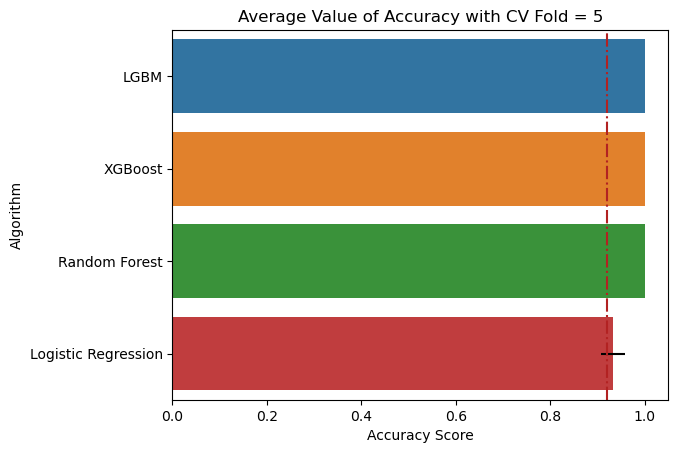

In [ ]:
sns.barplot(data = cv_total.sort_values(by = 'CV-Means',ascending=False), x = 'CV-Means', y = 'Algorithm',
            orient = 'h', **{'xerr': cv_std})
plt.xlabel('Accuracy Score')
plt.title('Average Value of Accuracy with CV Fold = 5')
plt.axvline(x = 0.92, color = 'firebrick', linestyle = '-.');

#### Insight:
As we can see from the graph above, it is need to be proven that LGBM, XGBoost, and Random Forest has a fairly high accuracy and relatively robust performance in various cross-validation folds. But looking at the Logistic Regression score, we think this model is the best model compared to other.

### 7.1.2 Hyperparameter Tuning Each Models

In [ ]:
cv_tuned = []

def Model_Performance(model_name, model):

    print(model_name)
    print('-----------------------------------------')
    print('        Best Score: ', str(model.best_score_)) # best_score_: Mean cross-validated score of the best_estimator
    print('   Best Parameters: ', str(model.best_params_))

    arg_min = np.argmin(model.cv_results_['rank_test_score'])
    scores_list = []
    for i in ['split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score']:
        scores_list.append(model.cv_results_[i][arg_min])

    cv_tuned.append({'Model': model_name,
                     'CV Scores': scores_list})

print ('Function ready!')

Function ready!


#### 7.1.2.1 XBoost

In the above model, we still use the base parameter from our model. To improve the accuracy of the models, we will tune the parameters in these models.

On XGBoost, the parameters we will be tuning are as follows:
- `learning_rate = .01, 0.03`
- `max_depth =  4, 7`
- `min_child_weight = 0, 4`
- `subsample = 0.7`
- `colsample_bytree = 0.3, 0.7`
- `n_estimators = 500, 1000`

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
xgb = XGBClassifier(random_state=random_state)

param_grid = {'learning_rate': [.01, 0.03], #eta
              'max_depth': [4,7],
              'min_child_weight': [0,4],
              'subsample': [0.7],
              'colsample_bytree': [0.3, 0.7],
              'n_estimators': [500,1000]}

tuned_xgb = RandomizedSearchCV(xgb, param_grid, cv = 5,
                        scoring = 'accuracy', verbose = True, n_jobs = 1)
best_tuned_xgb = tuned_xgb.fit(X_train, y_train)
Model_Performance('XGBoostClassifier', best_tuned_xgb)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
XGBoostClassifier
-----------------------------------------
        Best Score:  1.0
   Best Parameters:  {'subsample': 0.7, 'n_estimators': 1000, 'min_child_weight': 0, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


From the process that has been carried out above, we can get the XGBoost model which have very high accuracy score that equivalent with base parameters model through the Hyperparameter Tuning process.

With RandomizedSearchCV, a model with certain parameters is obtained to get an accuracy value of 100% (Not quite sure it's good 😅).

The accuracy value is very high (100%) and it can be concluded that the model is need to be validated again for the data modeling.

#### 7.1.2.2 Random Forest

On Random Forest, the parameters we will be tuning are as follows:
- `max_features = 'auto'`
- `max_depth = 30,80`
- `min_samples_split = 4,10`
- `min_samples_leaf = 1,4`
- `bootstrap = True,False`
- `n_estimators = 300,700`

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
rf = RandomForestClassifier(random_state=random_state)

param_grid = {'max_features': ['auto'],
              'max_depth': [30,80],
              'min_samples_split': [4,10],
              'min_samples_leaf': [1,4],
              'bootstrap': [True,False],
              'n_estimators': [300,700]}

tuned_rf = RandomizedSearchCV(rf, param_grid, cv = 5,
                        scoring = 'accuracy', verbose = True, n_jobs = 1)
best_tuned_rf = tuned_rf.fit(X_train, y_train)
Model_Performance('RandomForest Classifier', best_tuned_rf)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
RandomForest Classifier
-----------------------------------------
        Best Score:  1.0
   Best Parameters:  {'n_estimators': 700, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'auto', 'max_depth': 80, 'bootstrap': True}


From the process that has been carried out above, we can get the RF model which have a higher accuracy score that equivalent with base parameters model through the Hyperparameter Tuning process.

With RandomizedSearchCV, a model with certain parameters is obtained to get an accuracy value of 100% (Not quite sure it's good 😅).

The accuracy value is very high and it can be concluded that the model is need to be validated again for the data modeling.

#### 7.1.2.3 LGBM

On LGBM, the parameters we will be tuning are as follows:
- `learning_rate = 0.01, 0.1`
- `max_depth = 5, 10, 15`
- `num_leaves = 250, 500`
- `feature_fraction = 0.4, 0.6, 0.8`
- `min_child_samples = 5, 10, 20`

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
lgbm = LGBMClassifier(random_state=random_state)

param_grid = {'max_depth' : [5, 10, 15],    # Maximum tree depth, <=0 means no limit (default = -1)
              'learning_rate' : [0.01, 0.1],    # Boosting learning rate (default = 0.1)
              'n_estimators' : [250, 500],   # Number of boosted trees to fit (default = 100)
              'feature_fraction' : [0.4, 0.6, 0.8], #
              'min_child_samples' : [5, 10, 20]} # Minimum number of data needed in a leaf (default = 20)

tuned_lgbm = RandomizedSearchCV(lgbm, param_grid, cv = 5,
                        scoring = 'accuracy', verbose = True, n_jobs = 1)
best_tuned_lgbm = tuned_lgbm.fit(X_train, y_train)
Model_Performance('LGBM Classifier', best_tuned_lgbm)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 

From the process that has been carried out above, we can get the LGBM model which have a higher accuracy score that equivalent with base parameters model through the Hyperparameter Tuning process.

With RandomizedSearchCV, a model with certain parameters is obtained to get an accuracy value of 100% (Not quite sure it's good 😬).

The accuracy value is very high and it can be concluded that the model is need to be validated again for the data modeling.

#### 7.1.2.4 Logistic Regression

On Logistic Regression, the parameters we will be tuning are as follows:
- `solvers = 'newton-cg', 'lbfgs', 'liblinear'`
- `penalty = 'l2', 'l1', 'elasticnet'`
- `c_values = 100, 10, 1, 0.1, 0.01`

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
lr = LogisticRegression(random_state=random_state)

param_grid = {'solver' : ['newton-cg', 'lbfgs', 'liblinear'],
              'penalty' : ['l2','l1','elasticnet'],
              'C': [100,10,1,0.1,0.01]}

tuned_lr = RandomizedSearchCV(lr, param_grid, cv = 5,
                        scoring = 'accuracy', verbose = True, n_jobs = 1)
best_tuned_lr = tuned_lr.fit(X_train, y_train)
Model_Performance('Logistic Regression', best_tuned_lr)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Logistic Regression
-----------------------------------------
        Best Score:  0.958345428156749
   Best Parameters:  {'solver': 'newton-cg', 'penalty': 'l2', 'C': 100}


From the process that has been carried out above, we can get the best Logistic Regression model which have a higher accuracy score than the model with base parameters through the Hyperparameter Tuning process.

WWith RandomizedSearchCV, a model with certain parameters is obtained to get an accuracy value of 0.931≈93%.

The accuracy value is quite high and it can be concluded that the model is suitable for data modeling.

### 7.1.3 Learning Curve

The Learning Curve is a stage to see how efficient the model is in "learning new data" so that it can predict the model well. Usually, the more data used for learning, the higher the accuracy value of the model.

In this section below, we will see the learning curve of each model.

In [ ]:
#set train size
#264 x 80% = 211 (20% for validation)
train_sizes = [1, 20, 50, 100, 150, 211]

In [ ]:
from sklearn.model_selection import learning_curve
def learn_curve_plot(estimator, x, y, cv, train_sizes):
  train_sizes, train_scores, validation_scores = learning_curve(estimator,X=X,y=y, train_sizes= train_sizes, cv=cv)
  train_scores_mean = train_scores.mean(axis=1)
  validation_scores_mean = validation_scores.mean(axis=1)

  #Print
  print('Mean training scores\n\n', pd.Series(train_scores_mean, index=train_sizes))
  print('\n', '-' * 20) # separator
  print('\nMean validation scores\n\n',pd.Series(validation_scores_mean, index=train_sizes))

  plt.style.use('seaborn')
  plt.plot(train_sizes, train_scores_mean, label = 'Training error')
  plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
  plt.ylabel('Accuracy', fontsize = 14)
  plt.xlabel('Training set size', fontsize = 14)
  plt.title('Learning Curve', fontsize = 18, y = 1.03)
  plt.legend()

#### 7.1.3.1 XGBoost

Mean training scores

 1      NaN
20     1.0
50     1.0
100    1.0
150    1.0
211    1.0
dtype: float64

 --------------------

Mean validation scores

 1           NaN
20     0.993939
50     1.000000
100    1.000000
150    1.000000
211    1.000000
dtype: float64


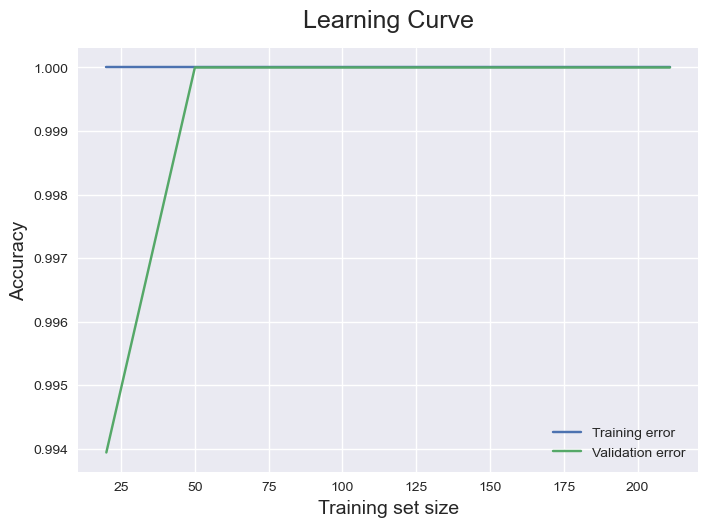

In [ ]:
learn_curve_plot(estimator=XGBClassifier(**best_tuned_xgb.best_params_,random_state=random_state), x=X, y=y, cv=5, train_sizes=train_sizes)

In the XGBoost model, we can see a significant increase in accuracy at the 0-50 interval training set. After that, the value increases fairly steadily as more data is learnt.

The gap between the Training Error and Validation Error is tiny (almost no gap), which means that this model has a relatively low variance.

We will jump to the Logistic Regression learning curve to evaluate how is performance model in predicting new data.

#### 7.1.3.2 Random Forest

Mean training scores

 1      1.000
20     0.840
50     0.924
100    0.996
150    1.000
211    1.000
dtype: float64

 --------------------

Mean validation scores

 1      0.051515
20     0.948485
50     0.948485
100    0.978788
150    0.996970
211    1.000000
dtype: float64


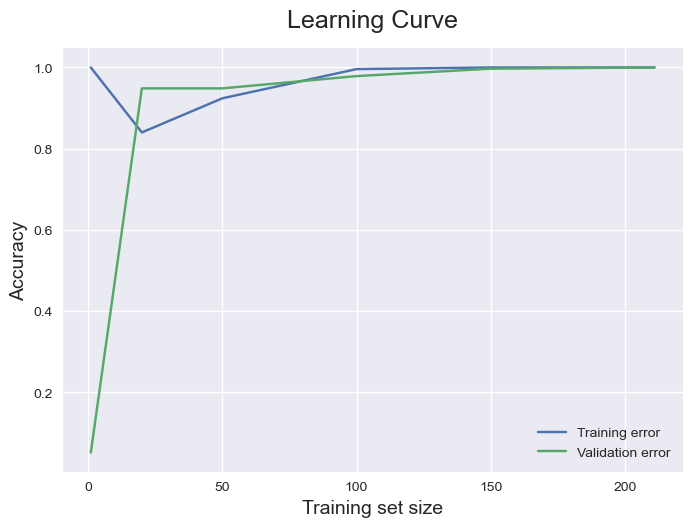

In [ ]:
learn_curve_plot(estimator=RandomForestClassifier(**best_tuned_rf.best_params_,random_state=random_state), x=X, y=y, cv=5, train_sizes=train_sizes)

#### 7.1.3.3 LGBM

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGB

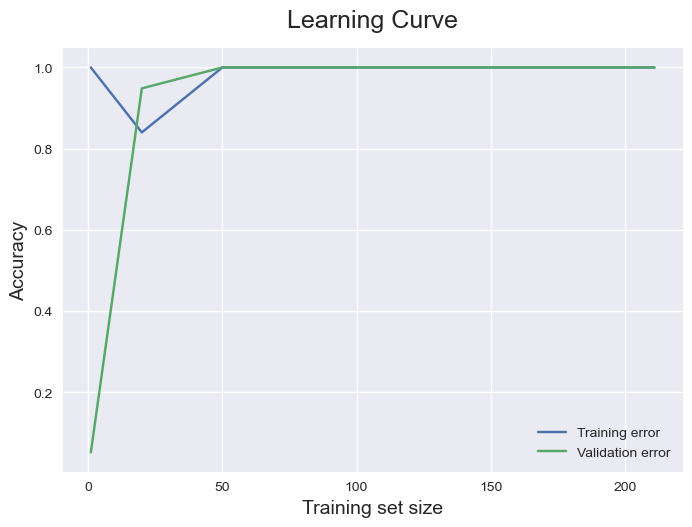

In [ ]:
learn_curve_plot(estimator=LGBMClassifier(**best_tuned_lgbm.best_params_,random_state=random_state), x=X, y=y, cv=5, train_sizes=train_sizes)

#### 7.1.3.4 Logistic Regression

Mean training scores

 1           NaN
20     0.900000
50     0.936000
100    0.944000
150    0.956000
211    0.961137
dtype: float64

 --------------------

Mean validation scores

 1           NaN
20     0.772727
50     0.939394
100    0.960606
150    0.960606
211    0.960606
dtype: float64


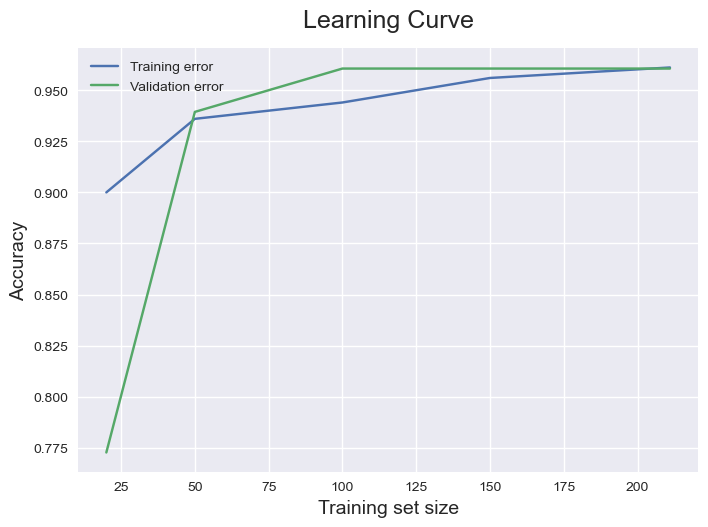

In [ ]:
learn_curve_plot(estimator=LogisticRegression(**best_tuned_lr.best_params_,random_state=random_state), x=X, y=y, cv=5, train_sizes=train_sizes)

In the XGBoost model, we can see a significant increase in accuracy at the 0-100 interval training set. After that, the value increases as more data is learnt.

The gap between the Training Error and Validation Error is quite high (> 0.1) in the beginning, which means that this model has a relatively high variance.

### 7.1.4 ROC-AUC Analysis

In [ ]:
y_pred_xgb = best_tuned_xgb.predict_proba(X_test)[:, 1].round()
y_pred_lr = best_tuned_lr.predict_proba(X_test)[:, 1].round()
y_pred_rf = best_tuned_rf.predict_proba(X_test)[:, 1].round()
y_pred_lgbm = best_tuned_lgbm.predict_proba(X_test)[:, 1].round()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
auc_xgb = roc_auc_score(y_test, y_pred_xgb)
auc_lr = roc_auc_score(y_test, y_pred_lr)
auc_rf = roc_auc_score(y_test, y_pred_rf)
auc_lgbm = roc_auc_score(y_test, y_pred_lgbm)

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_pred_lgbm)

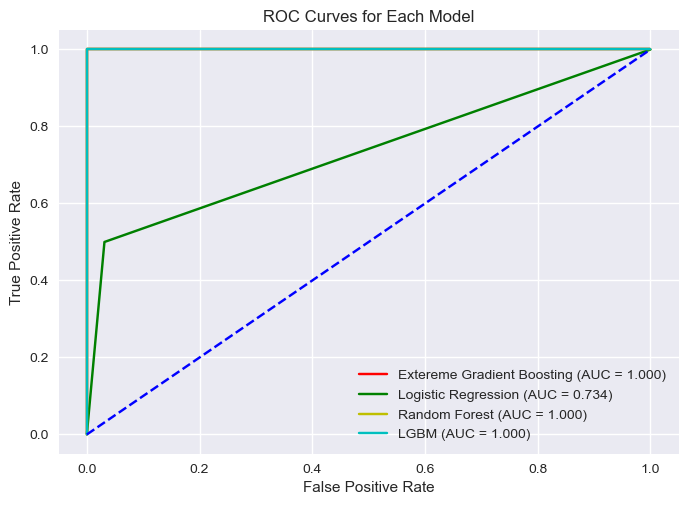

In [ ]:
# Plot ROC curves
plt.plot(fpr_xgb, tpr_xgb, label=f'Extereme Gradient Boosting (AUC = {auc_xgb:.3f})', color='r')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='g')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='y')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LGBM (AUC = {auc_lgbm:.3f})', color='c')
plt.plot([0, 1], [0, 1], linestyle='--', color='blue') #No-Skill Model

# Format the plot
plt.title('ROC Curves for Each Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

#### Insight:
From the graph above, we can see the ROC-AUC curve of each model that has been tuned for hyperparameters. From this curve, we can see the strong performance of the model in predicting classes 0 and 1.

The highest AUC value was achieved by the XGBoost, LGBM, and Random Forest model with an AUC value of 100%. This value is considered very high and need to be validated again. Since they are look stray, we decided to choose Logistic Regression with AUC score 73.4%. Prior evaluation with accuracy score metrics used RandomisedCV was quite high about 93% and after conducted hyper parameter tuning it has even increased by 97%. It can be concluded that the Logistic Regression model is the most appropriate model to be used in modeling credit risk of the customers.

### 7.2 Conclusion

* We decided to choose Logistic Regression Model as our best model which have quite high accuracy score that equivalent with base parameters model through the Hyperparameter Tuning process (97%).
* The business can use this model to predict credit risk behavior of the customer to distinguish which one of the customers can have likelihood to default on repayment behavior by corncerning on the significant features in the model.
* We also have to be aware of younger customer, based on data analysis, they are tend to be worse in terms of loan repayment behavior.
* If the business would like to achieve 2% cumulative default rate, we can accept loan applications from individuals who are less likely to default. We can accept loans with a predicted default probability below a certain fixed threshold 2%. It's important to note that achieving a specific cumulative default rate involves a trade-off between accepting more loans (higher approval rate) and the risk of defaults. A lower threshold will result in fewer defaults but may also mean rejecting more applicants who might be good borrowers. Additionally, regulatory and ethical considerations may play a role in your lending decisions. It's essential to comply with legal requirements and ensure fair and responsible lending practices. In practice, financial institutions often use a combination of predictive modeling, risk assessment, and business strategy to make lending decisions that balance profitability and risk while meeting specific business goals.

* Characteristics of a defaulter based on our findings in historical data patterns and feature importance:
- Pegawai swasta are more likely to default on loans.
- Customers with more dependents tend to be worse in terms of repayment behavior.
- Married customers have a higher likelihood of being bad customers than single or divorce customers.
- Younger customers have more likelihood of being default on loan. Specifically, customers between 25 - 30 yo are tend to be bad customers.
- Majority of the customers tend to be worse in terms of repayment behavior are customers who have outstanding balance Rp 1-2 mio, loan_installment and paid around 500K.

### Assignment 6 - Further Improvement

If you have had more time, what would you recommend to further improve the model and why?

Further improvement:
* Explore more feature engineering using Featuretools library. Basically it's **a Deep Feature Synthesis**. In simple terms, it is stacking transformations and aggregations of basic features on top of each other to create new features than can be useful for data modeling to get the best model with some essential features.
* Increase sample training & testing dataset through a proper data preprocessing because in the end of data cleaning process, we gain a few sample data for data modeling process.
* Since there's no dataset description, can add dataset description for more better data understanding. Hence, can do better on crunching data and addressing proper query with the right assumptions.

## Assignment 7
At JULO, we have 6 values that we follow, that are following our two core values:

![6 Core Values](julo_values.png)

A. Please choose three Core Values from the 6 values above that you think is your strength, share us one specific example where you showed it

As a data scientist, I have always strived to embody the core values of **excellence, effective team player, and responsibility** in every aspect of my work. I had the chance to put these core values into practice through a project that not only illustrated how important they are but also had a significant effect on the organization.

The pursuit of **excellence** has guided me along my data science path. When faced with a challenging issue,  I sought not just to find a solution but to find the best possible solution. I went deep into research and experimenting for a recent project where we wanted to optimize a crucial algorithm. I did not spare any research or experimentation. This dedication to perfection ultimately resulted in a discovery that dramatically enhanced the performance of our model, and winning praise from both coworkers and leadership.

Another important core value that I cherish is **effective teamwork**. In a data-driven world, collaboration is crucial.  During a project to build a predictive analytics system when I worked as a Data Analyst at Petrosea, I worked closely with a diverse team of data engineers, stakeholders, and domain experts. I actively sought their input, fostering an environment where ideas flowed freely. By being an effective team player, I not only contributed my expertise but also leveraged the collective intelligence of the team to deliver a solution that exceeded our initial expectations.

Data scientists have a **responsibility** to utilize data ethically in addition to just evaluating data. I made sure that our project met the greatest standards of accountability in an era where data security and privacy are crucial. We put in place strict data protection controls, upheld process transparency, and routinely checked our procedures for legal compliance. This dedication to appropriate data science increased stakeholder trust and protected the objectivity of our work.

In conclusion, in my capacity as a data scientist, this most recent project demonstrated the efficacy of these three guiding principles. Excellence drove me to innovate, effective teamwork increased our capacity, and responsibility assured honest and reliable results.  These values help to shape not only my professional identity but also the beneficial effects that data science may have on our organization and society at large.


B. Please choose three Core Values from the 6 values above that you think is your weakness, share us one specific example where you showed it

As a data scientist, I’m acutely aware of the importance of adhering to core values such as **work hard, critical, and transparency & openness.** However, I recognize that there are areas where I need to focus on improvement to align more closely with these values.

First, in terms of **work hard**, there have been times when I might not have performed to the best of my ability. I put a lot of effort into my work, but I also like to work smarter than harder. However, I am aware that there is always potential for improvement. In order to solve this, I'm deliberately establishing more challenging goals, using my time more effectively, and looking for professional development opportunities to make sure I'm always performing at my best.

Second, it is impossible to stress the importance of being **critical** in data science. Every project must be approached critically, with careful examination of the premises, procedures, and findings to spot any potential biases or inaccuracies. I could have been overly receptive of preliminary results in the past. I've put in place a more organized and thorough review procedure to address this. In order to provide more reliable results, I'm now more proactive about looking out for potential hazards and consistently questioning the validity of my analyses to produce more robust results.

Last, in data science, **transparency & openness** are crucial because they promote trust and cooperation. I've occasionally had trouble presenting thorough documentation of my work, including concise justifications of approaches and premises. To improve in this area, I'm consciously working to make my documentation more understandable so that stakeholders and coworkers can readily comprehend my procedures and findings. This move toward increased transparency will encourage candid conversations, ease collaboration, and eventually provide more reliable and reproducible results.

In conclusion, resolving these issues and making an effort to improve in terms of **work hard, critical, and transparency & openness** are crucial for my development as a data scientist. These initiatives not only improve my own performance but also foster quality and trust among our data science team members, which eventually benefits our firm as a whole.


C. Please order the 6 Core Values based on your priority if you work at JULO and why

Prioritizing these core values in my role as a data scientist at JULO, I would order them as follows:


1. **Committed to Excellence**: Being devoted to excellence as a data scientist means consistently striving to produce the highest quality work. This entails pushing the limits of what is feasible in addition to providing accurate and insightful analysis. For instance, if I was entrusted with creating a predictive model, I would spend time investigating cutting-edge algorithms and optimizing model parameters to produce the most precise prediction.

2. **Work Hard**: Working hard goes hand-in-hand with excellence. It means investing the necessary time and energy to adequately comprehend difficult facts, rigorously test hypotheses, and provide meaningful insights. An illustration of this value in action would be putting in extra time to meet project deadlines, particularly when faced with unforeseen data problems or tight schedules.

3. **Responsible**: Responsibility is critical in data science, especially when it comes to ethics and data protection. A trustworthy data scientist makes sure that data is handled with care while adhering to corporate guidelines and privacy laws. In actuality, this can entail the anonymization of sensitive data and the implementation of strict data security procedures to safeguard sensitive data.

4. **Effective Team Players**: Collaboration with cross-functional teams is common in data science. Effective team members actively interact with the coworkers, actively seeking their input and promoting an atmosphere of open communication. For instance, a good data scientist might schedule monthly meetings for the team working on a complicated analytics project to go over progress, share insights, and make sure everyone is on the same page with the project's objectives.

5. **Critical**: To assure the highest level of accuracy and reliability in data analysis, being critical entails carefully examining assumptions, techniques, and findings. A critical data scientist would routinely evaluate potential biases and cast doubt on the veracity of findings. For instance, we would thoroughly evaluate any unexpected results to find any methodological or data quality issues.

6. **Strive for Transparency and Openness**: Transparency and openness are important, but the other values frequently make them possible. Clear documentation of methodologies and assumptions would help coworkers and stakeholders to understand and confirm the work of a data scientist who aspires for transparency. Additionally, they would promote candid conversations and helpful criticism. For instance, we might provide thorough documentation along with the analysis results to facilitate discussions about potential improvements or alternative approaches.


